# Apple App Store — Exploratory Data Analysis

**Author:** Mohd. Gaus Khan

An end-to-end EDA of ~1.2M Apple App Store listings: data cleaning, feature engineering, and a
16-question business analysis covering category performance, pricing, ratings, developer output,
and revenue drivers.

**Skills demonstrated:** data cleaning · missing-value & duplicate handling · feature engineering ·
exploratory data analysis · statistical summarization · data visualization (Matplotlib, Seaborn) ·
business-insight storytelling

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn


## Dataset

- **Source:** Apple App Store — [Kaggle: Apple AppStore Apps](https://www.kaggle.com/datasets/gauthamp10/apple-appstore-apps)
- **Snapshot date:** October 2021
- **Scale:** ~1.2M app records across 21 attributes


## Objective

Conduct a thorough exploratory analysis of the App Store dataset to surface actionable insights on
category performance, pricing, ratings, and developer output — insights that could help developers
and stakeholders understand customer dynamics and prioritize where to invest.

**Approach:**
1. Load, clean, and validate the raw dataset.
2. Engineer features needed for downstream analysis.
3. Answer 16 targeted business questions with supporting visualizations.
4. Summarize findings into a concise set of takeaways.


## Key Insights at a Glance

- 🎮 **Games** dominate the App Store by both download volume and free/paid app count.
- ⭐ **Weather** apps carry the highest average user rating of any genre, narrowly ahead of Games.
- 📈 **2020** saw the highest number of app releases — plausibly a COVID-19 lockdown effect.
- 💲 App **size (MB) has little relationship with price** — larger apps aren't priced higher, with few exceptions.
- 🎓 **Educational apps** generate disproportionately high revenue relative to other genres.
- ⚠️ The `Content_Rating` field is noisy — a "9+" rating doesn't reliably guarantee age-appropriate content.

*(Full detail and supporting analysis for each point is in the Business Questions and Conclusion sections below.)*


## Libraries Used

| Library | Purpose |
|---|---|
| **Pandas** | Data manipulation and analysis |
| **NumPy** | Numerical computing |
| **Matplotlib** | Data visualization |
| **Seaborn** | Statistical data visualization |
| **SciPy** | Scientific computing utilities |



---

##### Data libraries

In [4]:
import pandas as pd                                     # Standard Data Analysis Library
import numpy as np                                      # Standard Numerical Library

##### Visualization libraries

In [5]:
import matplotlib.pyplot as plt                         # Standard Plotting Library
import seaborn as sns                                   # Enhanced Plotting Library                                     

##### Scientific libraries

In [6]:
# import scipy as sp                                      # Standard Scientific Library

---

## Part 1 · Data Preparation

### 1. Data Loading & Initial Exploration

**We will proceed as follow:**

- Load the csv file with the pandas
 
- Creating the dataframe and understanding the data present in the dataset
 
- Dealing with the missing data and the incorrect records

---

**I. Load dataset**

In [8]:
df =  pd.read_csv('../1_data/apple_data.csv')

**II.   This code snippet helps you get a complete overview of your data set**

In [10]:
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None)

**III. Get a sneak peek of your data**

In [11]:
df.head()

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,Free,DeveloperId,Developer,Developer_Url,Developer_Website,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews
0,com.hkbu.arc.apaper,A+ Paper Guide,https://apps.apple.com/us/app/a-paper-guide/id...,Education,4+,21993472.0,8.0,2017-09-28T03:02:41Z,2018-12-21T21:30:36Z,1.1.2,0.00,USD,True,1375410542,HKBU ARC,https://apps.apple.com/us/developer/hkbu-arc/i...,NaN,0.0,0,0.0,0
1,com.dmitriev.abooks,A-Books,https://apps.apple.com/us/app/a-books/id103157...,Book,4+,13135872.0,10.0,2015-08-31T19:31:32Z,2019-07-23T20:31:09Z,1.3,0.00,USD,True,1031572001,Roman Dmitriev,https://apps.apple.com/us/developer/roman-dmit...,NaN,5.0,1,5.0,1
2,no.terp.abooks,A-books,https://apps.apple.com/us/app/a-books/id145702...,Book,4+,21943296.0,9.0,2021-04-14T07:00:00Z,2021-05-30T21:08:54Z,1.3.1,0.00,USD,True,1457024163,Terp AS,https://apps.apple.com/us/developer/terp-as/id...,NaN,0.0,0,0.0,0
3,fr.antoinettefleur.Book1,A-F Book #1,https://apps.apple.com/us/app/a-f-book-1/id500...,Book,4+,81851392.0,8.0,2012-02-10T03:40:07Z,2019-10-29T12:40:37Z,1.2,2.99,USD,False,439568839,i-editeur.com,https://apps.apple.com/us/developer/i-editeur-...,NaN,0.0,0,0.0,0
4,com.imonstersoft.azdictionaryios,A-Z Synonyms Dictionary,https://apps.apple.com/us/app/a-z-synonyms-dic...,Reference,4+,64692224.0,9.0,2020-12-16T08:00:00Z,2020-12-18T21:36:11Z,1.0.1,0.00,USD,True,656731821,Ngov chiheang,https://apps.apple.com/us/developer/ngov-chihe...,http://imonstersoft.com,0.0,0,0.0,0


**IV. View the column names**

In [12]:
df.columns
# print(df.columns)                                  # alternative                      

Index(['App_Id', 'App_Name', 'AppStore_Url', 'Primary_Genre', 'Content_Rating',
       'Size_Bytes', 'Required_IOS_Version', 'Released', 'Updated', 'Version',
       'Price', 'Currency', 'Free', 'DeveloperId', 'Developer',
       'Developer_Url', 'Developer_Website', 'Average_User_Rating', 'Reviews',
       'Current_Version_Score', 'Current_Version_Reviews'],
      dtype='str')

**V. View the shape of the dataset**

In [13]:
print(f"The dataframe has {df.shape[0]} rows and {df.shape[1]} columns")

The dataframe has 1230376 rows and 21 columns


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1230376 entries, 0 to 1230375
Data columns (total 21 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   App_Id                   1230376 non-null  str    
 1   App_Name                 1230375 non-null  str    
 2   AppStore_Url             1230376 non-null  str    
 3   Primary_Genre            1230376 non-null  str    
 4   Content_Rating           1230376 non-null  str    
 5   Size_Bytes               1230152 non-null  float64
 6   Required_IOS_Version     1230376 non-null  str    
 7   Released                 1230373 non-null  str    
 8   Updated                  1230376 non-null  str    
 9   Version                  1230376 non-null  str    
 10  Price                    1229886 non-null  float64
 11  Currency                 1230376 non-null  str    
 12  Free                     1230376 non-null  bool   
 13  DeveloperId              1230376 non-null  int64  
 1

**VI. Descriptive Statistics**

We use descriptive statistics to summarize and understand the key features of dataset.

In [15]:
df.describe()

,Size_Bytes,Price,DeveloperId,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews
count,1.230152e+06,1.229886e+06,1.230376e+06,1.230376e+06,1.230376e+06,1.230376e+06,1.230376e+06
mean,7.510857e+07,5.041264e-01,1.092869e+09,1.788387e+00,8.259478e+02,1.788387e+00,8.259478e+02
std,2.318726e+08,6.869674e+00,4.090897e+08,2.154105e+00,5.016051e+04,2.154105e+00,5.016051e+04
min,2.762800e+04,0.000000e+00,2.816565e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.041344e+07,0.000000e+00,7.381109e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.333158e+07,0.000000e+00,1.179711e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.365466e+07,0.000000e+00,1.471960e+09,4.333330e+00,3.000000e+00,4.333330e+00,3.000000e+00
max,7.677945e+10,9.999900e+02,1.590233e+09,5.000000e+00,2.268533e+07,5.000000e+00,2.268533e+07


**VII. Missing values in the data**

In [16]:
# df.isnull()                                          # To see the null values in the dataframe
# df.isnull().sum()                                    # To see the total number of null values                        
# df.isnull().sum()/len(df)*100                        # To see the percentage of null values
df.isnull().sum().sort_values(ascending=False)         # To see the total number of null values in descending order

Developer_Website          643988
Developer_Url                1109
Price                         490
Size_Bytes                    224
Released                        3
App_Name                        1
Primary_Genre                   0
AppStore_Url                    0
App_Id                          0
Content_Rating                  0
Version                         0
Updated                         0
Required_IOS_Version            0
Free                            0
Currency                        0
Developer                       0
DeveloperId                     0
Average_User_Rating             0
Reviews                         0
Current_Version_Score           0
Current_Version_Reviews         0
dtype: int64

**Observations**
1. The dataset has 1,230,376 rows and 21 columns.
2. Seven columns are numeric.
3. Six columns contain missing values.

---

### 2. Missing Value Analysis & Treatment

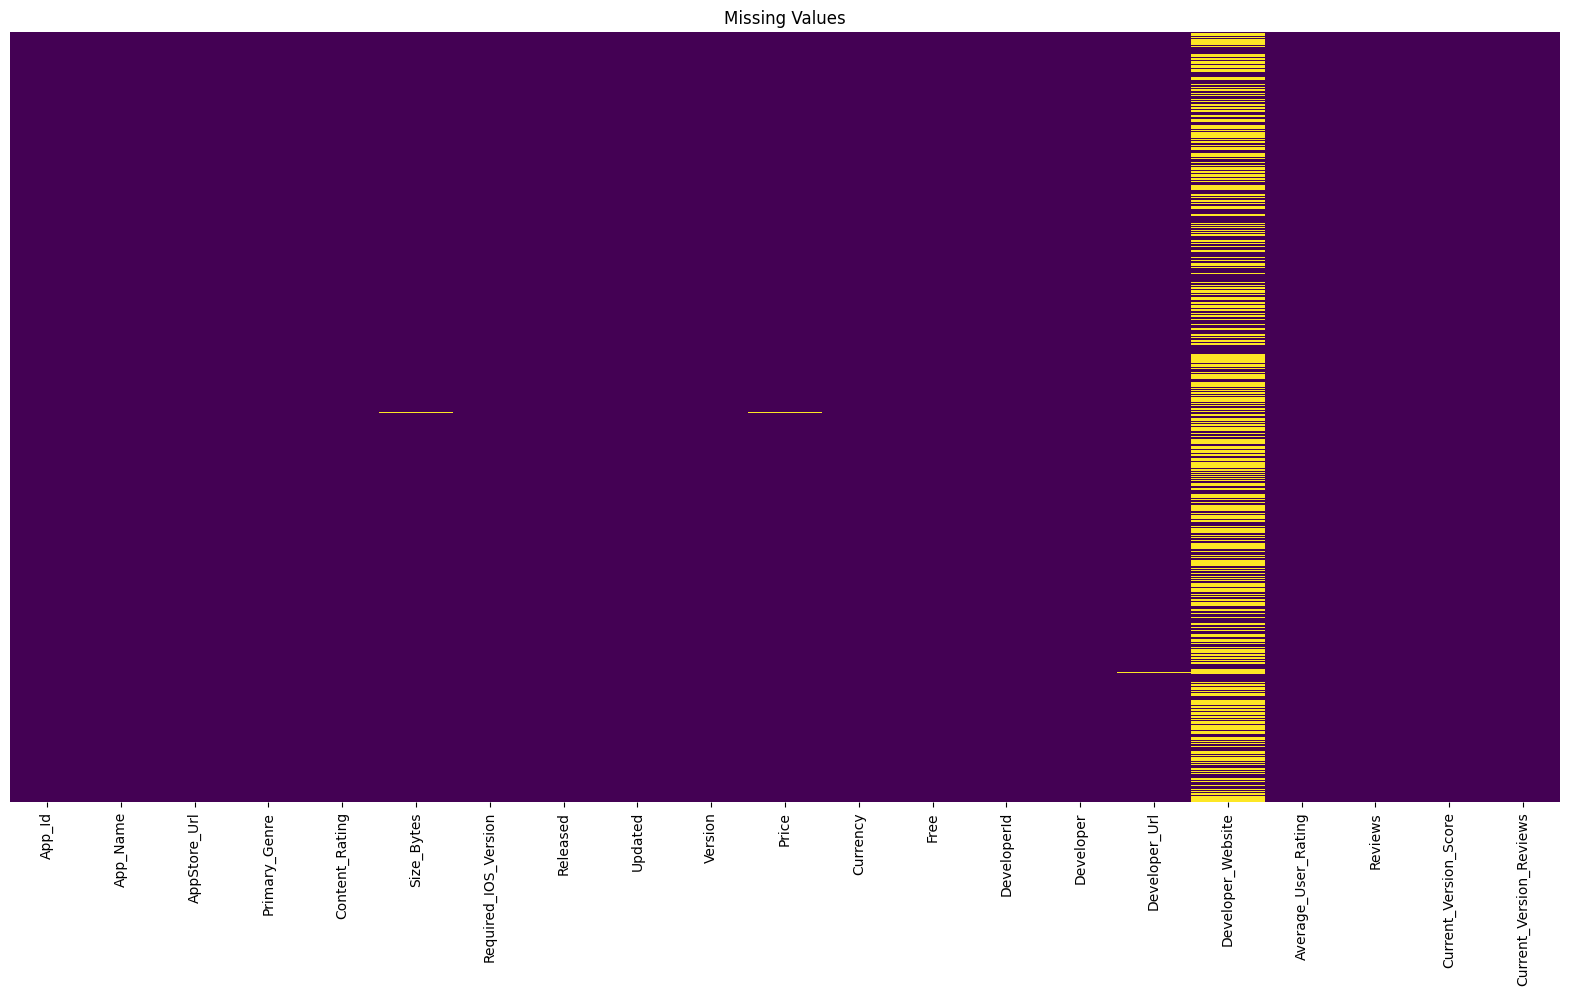

In [17]:
plt.rcParams['figure.figsize'] = [20, 10]
sns.heatmap(df.isnull(), yticklabels=False,cbar=False,cmap='viridis')
plt.title('Missing Values')
plt.show()

> **Figure 1:** Distribution of missing values across all columns.


- See the percentage of null values in your dataset sorted in ascending order, making it easy to identify which features have the most missing data.

In [18]:
missing_percentage = (df.isnull().sum().sort_values(ascending = False)/len(df))*100
missing_percentage

Developer_Website          52.340748
Developer_Url               0.090135
Price                       0.039825
Size_Bytes                  0.018206
Released                    0.000244
App_Name                    0.000081
Primary_Genre               0.000000
AppStore_Url                0.000000
App_Id                      0.000000
Content_Rating              0.000000
Version                     0.000000
Updated                     0.000000
Required_IOS_Version        0.000000
Free                        0.000000
Currency                    0.000000
Developer                   0.000000
DeveloperId                 0.000000
Average_User_Rating         0.000000
Reviews                     0.000000
Current_Version_Score       0.000000
Current_Version_Reviews     0.000000
dtype: float64

- We will generate a graphical representation of the percentage of null values by plotting the data using an appropriate charting technique

Text(0.5, 1.0, 'Percentage of null values')

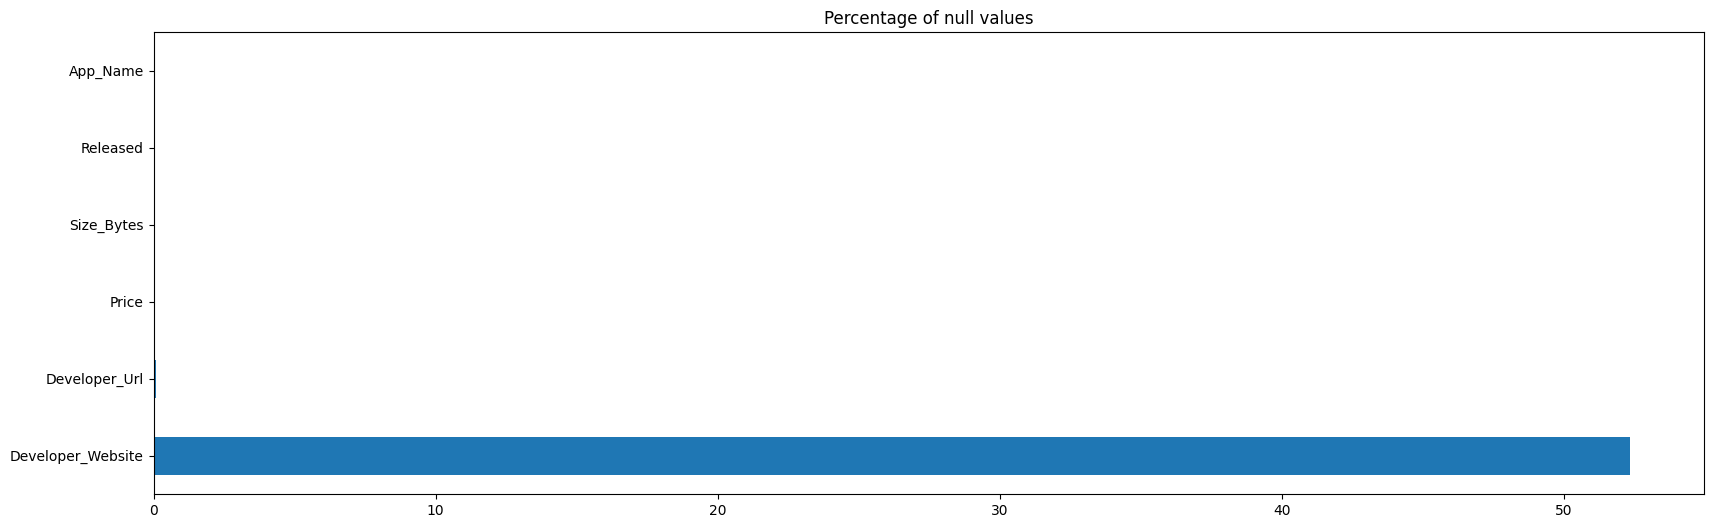

In [19]:
missing_percentage = missing_percentage[missing_percentage != 0] # Only the missing data
plt.rcParams['figure.figsize'] = (20,6)
missing_percentage.plot(kind = 'barh')
plt.title("Percentage of null values")

> **Figure 2:** Percentage of missing values by column (non-zero only).


- Given its limited relevance and high proportion of NULL values, we drop this attribute from the dataset.

In [20]:
df.drop('Developer_Website', axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1230376 entries, 0 to 1230375
Data columns (total 20 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   App_Id                   1230376 non-null  str    
 1   App_Name                 1230375 non-null  str    
 2   AppStore_Url             1230376 non-null  str    
 3   Primary_Genre            1230376 non-null  str    
 4   Content_Rating           1230376 non-null  str    
 5   Size_Bytes               1230152 non-null  float64
 6   Required_IOS_Version     1230376 non-null  str    
 7   Released                 1230373 non-null  str    
 8   Updated                  1230376 non-null  str    
 9   Version                  1230376 non-null  str    
 10  Price                    1229886 non-null  float64
 11  Currency                 1230376 non-null  str    
 12  Free                     1230376 non-null  bool   
 13  DeveloperId              1230376 non-null  int64  
 1

In [21]:
#filling mean value of Price column in the null places of that column
df['Price'] = df.Price.fillna(value=df['Price'].mean())
df['Size_Bytes'] = df.Size_Bytes.fillna(value=df['Size_Bytes'].mean())

# Verify the updated null-value counts
df.isnull().sum().sort_values(ascending = False)

Developer_Url              1109
Released                      3
App_Name                      1
App_Id                        0
Primary_Genre                 0
AppStore_Url                  0
Size_Bytes                    0
Content_Rating                0
Updated                       0
Version                       0
Price                         0
Required_IOS_Version          0
Currency                      0
Free                          0
DeveloperId                   0
Developer                     0
Average_User_Rating           0
Reviews                       0
Current_Version_Score         0
Current_Version_Reviews       0
dtype: int64

**Observations**
1. `Developer_Website` has the highest percentage of null values — dropped.
2. `Price` and `Size_Bytes` are important columns, so nulls there are imputed rather than dropped.

- Let's look at rows where each remaining column has null values.

In [22]:
df[df['Developer_Url'].isnull()].head(5)

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,Free,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews
2382,com.TroopAdmin2,C&S Troop Admin,https://apps.apple.com/us/app/c-s-troop-admin/...,Business,4+,87355392.0,10.0,2021-06-04T07:00:00Z,2021-06-05T03:40:31Z,1.0,0.0,USD,True,1569780624,Hunter Biscuit & Wolf Limited,NaN,0.00000,0,0.00000,0
2827,com.dhrubajyoti.bangla,Bangla Rhymes,https://apps.apple.com/us/app/bangla-rhymes/id...,Education,4+,56445952.0,9.1,2019-03-23T18:27:49Z,2019-03-23T18:27:49Z,1.0.1,0.0,USD,True,1452131894,Dhrubajyoti Dey,NaN,5.00000,5,5.00000,5
3498,com.f1rstmotors.f1rstmotors,F1RST MOTORS,https://apps.apple.com/us/app/f1rst-motors/id1...,Business,4+,77185024.0,13.0,2021-10-06T07:00:00Z,2021-10-06T12:15:27Z,1.0,0.0,USD,True,1588267041,F1RST MOTORS LLC,NaN,0.00000,0,0.00000,0
5820,tr.com.okuvaryum.mobil,Okuvaryum,https://apps.apple.com/us/app/okuvaryum/id1493...,Education,4+,79869952.0,11.0,2020-01-17T08:00:00Z,2021-05-29T15:20:58Z,1.0.21,0.0,USD,True,1589915483,OKUVARYUM EGITIM VE TEKNOLOJI ANONIM SIRKETI,NaN,4.44444,9,4.44444,9
5821,tr.com.okuvaryum.okul,Okuvaryum Okul,https://apps.apple.com/us/app/okuvaryum-okul/i...,Education,4+,39526400.0,11.0,2021-08-25T07:00:00Z,2021-10-08T17:07:59Z,1.0.2,0.0,USD,True,1589915483,OKUVARYUM EGITIM VE TEKNOLOJI ANONIM SIRKETI,NaN,0.00000,0,0.00000,0


In [23]:
df[df['Released'].isnull()].head(5)

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,Free,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews
264853,com.ironhidegames.frontiers.universal.premium,Kingdom Rush Frontiers TD+,https://apps.apple.com/us/app/kingdom-rush-fro...,Games,12+,7.510857e+07,13.0,NaN,2021-11-12T08:00:00Z,5.4.15,0.504126,USD,False,1542047256,Ironhide Irl,https://apps.apple.com/us/developer/ironhide-i...,0.0,0,0.0,0
836858,com.redgamesco.transformers,Transformers: Tactical Arena,https://apps.apple.com/us/app/transformers-tac...,Games,9+,7.510857e+07,13.5.0,NaN,2021-11-05T07:00:00Z,0.1,0.504126,USD,False,1456007507,"RED GAMES CO, LLC",https://apps.apple.com/us/developer/red-games-...,0.0,0,0.0,0
919513,com.crayolallc.crayola-create-and-play-plus,Crayola Create and Play+,https://apps.apple.com/us/app/crayola-create-a...,Games,4+,7.510857e+07,13,NaN,2021-10-29T07:00:00Z,1.52,0.504126,USD,False,1456007507,"RED GAMES CO, LLC",https://apps.apple.com/us/developer/red-games-...,0.0,0,0.0,0


In [24]:
df[df['App_Name'].isnull()].head(5)

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,Free,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews
964888,se.promedia.NA,NaN,https://apps.apple.com/us/app/na/id449134868?uo=4,News,4+,19528704.0,9.0,2011-08-08T11:45:30Z,2020-12-21T14:08:02Z,8.1.2,0.0,USD,True,449134871,Promedia,https://apps.apple.com/us/developer/promedia/i...,5.0,1,5.0,1


**Observations**

We could try to backfill `Developer_Url`, `Released`, and `App_Name` by matching the null row's
`App_Id` against other rows with the same App, but their unique nature makes this unreliable.

**Approach:** drop only the rows where `Developer_Url`, `Released`, or `App_Name` are null, to
preserve data integrity elsewhere in the dataset.

In [25]:
df.dropna(subset=['Developer_Url'], inplace=True)

df.dropna(subset=['Released'], inplace=True)

df.dropna(subset=['App_Name'], inplace=True)

In [26]:
# Verify the refreshed dataset
df.isnull().sum().sort_values(ascending = False)

App_Id                     0
App_Name                   0
AppStore_Url               0
Primary_Genre              0
Content_Rating             0
Size_Bytes                 0
Required_IOS_Version       0
Released                   0
Updated                    0
Version                    0
Price                      0
Currency                   0
Free                       0
DeveloperId                0
Developer                  0
Developer_Url              0
Average_User_Rating        0
Reviews                    0
Current_Version_Score      0
Current_Version_Reviews    0
dtype: int64

**Milestone 1:** the dataset is now free of null values. ✅


### 3. Duplicate Records Analysis

In [27]:
df.duplicated().any()                    # To see if there is any duplicate in dataset

np.False_

In [28]:
df.columns

Index(['App_Id', 'App_Name', 'AppStore_Url', 'Primary_Genre', 'Content_Rating',
       'Size_Bytes', 'Required_IOS_Version', 'Released', 'Updated', 'Version',
       'Price', 'Currency', 'Free', 'DeveloperId', 'Developer',
       'Developer_Url', 'Average_User_Rating', 'Reviews',
       'Current_Version_Score', 'Current_Version_Reviews'],
      dtype='str')

In [29]:
any_duplicates = df.duplicated(subset=['App_Id', 'App_Name', 'AppStore_Url', 'Primary_Genre', 'Content_Rating',
       'Size_Bytes', 'Required_IOS_Version', 'Released', 'Updated', 'Version',
       'Price', 'Currency', 'Free', 'DeveloperId', 'Developer',
       'Developer_Url', 'Average_User_Rating', 'Reviews',
       'Current_Version_Score', 'Current_Version_Reviews']).any()

In [30]:
boolean = df['App_Name'].duplicated().any()
boolean

np.True_

<Axes: xlabel='App_Name'>

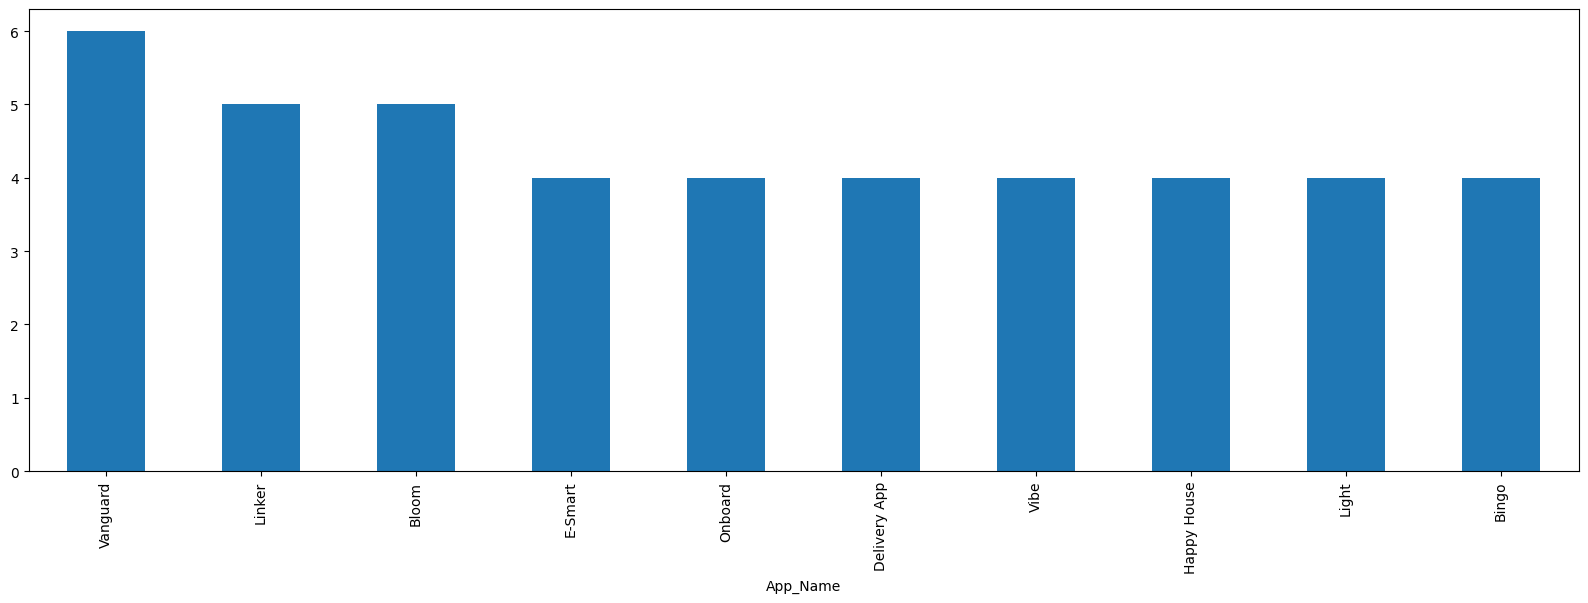

In [31]:
df['App_Name'].value_counts().nlargest(10).plot(kind='bar')

In [32]:
# df.groupby('App_Name').size().sort_values(ascending=False)
# you also use this code to see the top 10 most common app names in the dataset.

> The output above shows `App_Name` has multiple rows. Let's check whether those rows are true duplicates or distinct records.

In [33]:
df[df['App_Name'] == 'Linker']

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,Free,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews
139096,com.cheerg.LinkerTest,Linker,https://apps.apple.com/us/app/linker/id1208886...,Lifestyle,4+,21876736.0,10.0,2017-03-30T20:08:27Z,2018-06-14T20:39:23Z,1.0.14,0.0,USD,True,1208886054,Chun Hsiang Hsieh,https://apps.apple.com/us/developer/chun-hsian...,0.0,0,0.0,0
462132,br.com.linker,Linker,https://apps.apple.com/us/app/linker/id1472621...,Finance,4+,169309184.0,12.0,2019-08-22T07:00:00Z,2021-10-01T16:08:21Z,2.0.3,0.0,USD,True,1472621726,BEMP SOLUCOES DE PAGAMENTO LTDA,https://apps.apple.com/us/developer/bemp-soluc...,4.4,5,4.4,5
745039,team.linker.linker,Linker,https://apps.apple.com/us/app/linker/id1558364...,Health & Fitness,4+,97497088.0,10.0,2021-03-30T07:00:00Z,2021-08-23T11:16:44Z,1.0.7,0.0,USD,True,1558364892,Linker ApS,https://apps.apple.com/us/developer/linker-aps...,0.0,0,0.0,0
954862,com.kubo.Linker,Linker,https://apps.apple.com/us/app/linker/id1169163...,Travel,4+,34196480.0,7.0,2017-05-16T11:32:18Z,2017-10-10T01:56:27Z,39.2,0.0,USD,True,370982422,Kubo Mobile Applications SA,https://apps.apple.com/us/developer/kubo-mobil...,0.0,0,0.0,0
1206501,com.tilon.elcloud.rdc,Linker,https://apps.apple.com/us/app/linker/id1215552...,Utilities,4+,58948209.0,10.6.6,2017-05-30T19:54:25Z,2017-05-30T19:54:25Z,3.3.1,0.0,USD,True,355652681,"TILON CO., LTD.",https://apps.apple.com/us/developer/tilon-co-l...,0.0,0,0.0,0


**Milestone 2:** no true duplicates found. ✅

Although `App_Name` values repeat, each record is unique as a whole — apps appear multiple times
with different versions, `App_Id`s, and release dates.

---

### 4. Exploring Numeric Attributes

Reviewing the unique values across the dataset's numeric columns:
- `Size_Bytes`
- `Price`
- `DeveloperId`
- `Average_User_Rating`
- `Reviews`
- `Current_Version_Score`
- `Current_Version_Reviews`

In [34]:
df['Size_Bytes'].unique()

array([2.19934720e+07, 1.31358720e+07, 2.19432960e+07, ...,
       1.19404544e+08, 5.96570000e+05, 5.06896000e+05], shape=(255820,))

In [35]:
df['Price'].unique()

array([0.00000000e+00, 2.99000000e+00, 1.99000000e+00, 9.90000000e-01,
       4.99000000e+00, 9.99000000e+00, 5.99000000e+00, 6.99000000e+00,
       1.69900000e+01, 1.99900000e+01, 3.99900000e+01, 5.99900000e+01,
       8.99000000e+00, 7.99000000e+00, 1.89900000e+01, 3.99000000e+00,
       2.49900000e+01, 1.49900000e+01, 2.89900000e+01, 2.19900000e+01,
       1.39900000e+01, 1.09900000e+01, 1.19900000e+01, 1.29990000e+02,
       2.29900000e+01, 1.39990000e+02, 2.59900000e+01, 1.29900000e+01,
       4.99900000e+01, 2.39900000e+01, 1.19990000e+02, 7.99900000e+01,
       1.79900000e+01, 4.99990000e+02, 2.49990000e+02, 1.99990000e+02,
       2.29990000e+02, 3.49900000e+01, 2.09900000e+01, 9.99900000e+01,
       3.39900000e+01, 5.49900000e+01, 4.59900000e+01, 4.49900000e+01,
       2.99900000e+01, 6.99900000e+01, 2.79900000e+01, 8.49900000e+01,
       6.49900000e+01, 1.59900000e+01, 2.69900000e+01, 3.59900000e+01,
       4.09900000e+01, 1.74990000e+02, 1.49990000e+02, 9.49900000e+01,
      

In [36]:
df['DeveloperId'].unique()

array([1375410542, 1031572001, 1457024163, ..., 1532733861, 1522287989,
       1438594214], shape=(508620,))

In [37]:
df['Average_User_Rating'].unique()

array([0.     , 5.     , 4.78132, ..., 4.00352, 3.91608, 4.82733],
      shape=(45042,))

In [38]:
df['Reviews'].unique()

array([    0,     1,  1285, ..., 12691, 35476, 10481], shape=(13667,))

In [39]:
df['Current_Version_Score'].unique()

array([0.     , 5.     , 4.78132, ..., 4.00352, 3.91608, 4.82733],
      shape=(45042,))

In [40]:
df['Current_Version_Reviews'].unique()

array([    0,     1,  1285, ..., 12691, 35476, 10481], shape=(13667,))

In [41]:
df.head(5)

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,Free,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews
0,com.hkbu.arc.apaper,A+ Paper Guide,https://apps.apple.com/us/app/a-paper-guide/id...,Education,4+,21993472.0,8.0,2017-09-28T03:02:41Z,2018-12-21T21:30:36Z,1.1.2,0.00,USD,True,1375410542,HKBU ARC,https://apps.apple.com/us/developer/hkbu-arc/i...,0.0,0,0.0,0
1,com.dmitriev.abooks,A-Books,https://apps.apple.com/us/app/a-books/id103157...,Book,4+,13135872.0,10.0,2015-08-31T19:31:32Z,2019-07-23T20:31:09Z,1.3,0.00,USD,True,1031572001,Roman Dmitriev,https://apps.apple.com/us/developer/roman-dmit...,5.0,1,5.0,1
2,no.terp.abooks,A-books,https://apps.apple.com/us/app/a-books/id145702...,Book,4+,21943296.0,9.0,2021-04-14T07:00:00Z,2021-05-30T21:08:54Z,1.3.1,0.00,USD,True,1457024163,Terp AS,https://apps.apple.com/us/developer/terp-as/id...,0.0,0,0.0,0
3,fr.antoinettefleur.Book1,A-F Book #1,https://apps.apple.com/us/app/a-f-book-1/id500...,Book,4+,81851392.0,8.0,2012-02-10T03:40:07Z,2019-10-29T12:40:37Z,1.2,2.99,USD,False,439568839,i-editeur.com,https://apps.apple.com/us/developer/i-editeur-...,0.0,0,0.0,0
4,com.imonstersoft.azdictionaryios,A-Z Synonyms Dictionary,https://apps.apple.com/us/app/a-z-synonyms-dic...,Reference,4+,64692224.0,9.0,2020-12-16T08:00:00Z,2020-12-18T21:36:11Z,1.0.1,0.00,USD,True,656731821,Ngov chiheang,https://apps.apple.com/us/developer/ngov-chihe...,0.0,0,0.0,0


### 5. Feature Engineering

**5.1 App size in MB** — convert `Size_Bytes` to KB, then to MB, for a more readable unit.

In [42]:
df['Size_MB'] = df['Size_Bytes'].apply(lambda x: (float(x) / 1024)/1024)

In [43]:
df.head()

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,Free,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews,Size_MB
0,com.hkbu.arc.apaper,A+ Paper Guide,https://apps.apple.com/us/app/a-paper-guide/id...,Education,4+,21993472.0,8.0,2017-09-28T03:02:41Z,2018-12-21T21:30:36Z,1.1.2,0.00,USD,True,1375410542,HKBU ARC,https://apps.apple.com/us/developer/hkbu-arc/i...,0.0,0,0.0,0,20.974609
1,com.dmitriev.abooks,A-Books,https://apps.apple.com/us/app/a-books/id103157...,Book,4+,13135872.0,10.0,2015-08-31T19:31:32Z,2019-07-23T20:31:09Z,1.3,0.00,USD,True,1031572001,Roman Dmitriev,https://apps.apple.com/us/developer/roman-dmit...,5.0,1,5.0,1,12.527344
2,no.terp.abooks,A-books,https://apps.apple.com/us/app/a-books/id145702...,Book,4+,21943296.0,9.0,2021-04-14T07:00:00Z,2021-05-30T21:08:54Z,1.3.1,0.00,USD,True,1457024163,Terp AS,https://apps.apple.com/us/developer/terp-as/id...,0.0,0,0.0,0,20.926758
3,fr.antoinettefleur.Book1,A-F Book #1,https://apps.apple.com/us/app/a-f-book-1/id500...,Book,4+,81851392.0,8.0,2012-02-10T03:40:07Z,2019-10-29T12:40:37Z,1.2,2.99,USD,False,439568839,i-editeur.com,https://apps.apple.com/us/developer/i-editeur-...,0.0,0,0.0,0,78.059570
4,com.imonstersoft.azdictionaryios,A-Z Synonyms Dictionary,https://apps.apple.com/us/app/a-z-synonyms-dic...,Reference,4+,64692224.0,9.0,2020-12-16T08:00:00Z,2020-12-18T21:36:11Z,1.0.1,0.00,USD,True,656731821,Ngov chiheang,https://apps.apple.com/us/developer/ngov-chihe...,0.0,0,0.0,0,61.695312


> New `Size_MB` column added.

**5.2 Free vs. Paid app type** — derive a readable `Type` category from the boolean `Free` column.

In [44]:
df['Type'] = df['Free'].map({True: 'Free', False: 'Paid'}).astype('category')

# you can also use this alternatives
# df['Type'] = np.where(df['Free'] == True,'Free','Paid')

In [45]:
df.head()

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,Free,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews,Size_MB,Type
0,com.hkbu.arc.apaper,A+ Paper Guide,https://apps.apple.com/us/app/a-paper-guide/id...,Education,4+,21993472.0,8.0,2017-09-28T03:02:41Z,2018-12-21T21:30:36Z,1.1.2,0.00,USD,True,1375410542,HKBU ARC,https://apps.apple.com/us/developer/hkbu-arc/i...,0.0,0,0.0,0,20.974609,Free
1,com.dmitriev.abooks,A-Books,https://apps.apple.com/us/app/a-books/id103157...,Book,4+,13135872.0,10.0,2015-08-31T19:31:32Z,2019-07-23T20:31:09Z,1.3,0.00,USD,True,1031572001,Roman Dmitriev,https://apps.apple.com/us/developer/roman-dmit...,5.0,1,5.0,1,12.527344,Free
2,no.terp.abooks,A-books,https://apps.apple.com/us/app/a-books/id145702...,Book,4+,21943296.0,9.0,2021-04-14T07:00:00Z,2021-05-30T21:08:54Z,1.3.1,0.00,USD,True,1457024163,Terp AS,https://apps.apple.com/us/developer/terp-as/id...,0.0,0,0.0,0,20.926758,Free
3,fr.antoinettefleur.Book1,A-F Book #1,https://apps.apple.com/us/app/a-f-book-1/id500...,Book,4+,81851392.0,8.0,2012-02-10T03:40:07Z,2019-10-29T12:40:37Z,1.2,2.99,USD,False,439568839,i-editeur.com,https://apps.apple.com/us/developer/i-editeur-...,0.0,0,0.0,0,78.059570,Paid
4,com.imonstersoft.azdictionaryios,A-Z Synonyms Dictionary,https://apps.apple.com/us/app/a-z-synonyms-dic...,Reference,4+,64692224.0,9.0,2020-12-16T08:00:00Z,2020-12-18T21:36:11Z,1.0.1,0.00,USD,True,656731821,Ngov chiheang,https://apps.apple.com/us/developer/ngov-chihe...,0.0,0,0.0,0,61.695312,Free


> New `Type` column added; the original `Free` column is now redundant.

In [46]:
df.drop(['Free'],axis=1, inplace= True )

In [47]:
df.head(5)

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews,Size_MB,Type
0,com.hkbu.arc.apaper,A+ Paper Guide,https://apps.apple.com/us/app/a-paper-guide/id...,Education,4+,21993472.0,8.0,2017-09-28T03:02:41Z,2018-12-21T21:30:36Z,1.1.2,0.00,USD,1375410542,HKBU ARC,https://apps.apple.com/us/developer/hkbu-arc/i...,0.0,0,0.0,0,20.974609,Free
1,com.dmitriev.abooks,A-Books,https://apps.apple.com/us/app/a-books/id103157...,Book,4+,13135872.0,10.0,2015-08-31T19:31:32Z,2019-07-23T20:31:09Z,1.3,0.00,USD,1031572001,Roman Dmitriev,https://apps.apple.com/us/developer/roman-dmit...,5.0,1,5.0,1,12.527344,Free
2,no.terp.abooks,A-books,https://apps.apple.com/us/app/a-books/id145702...,Book,4+,21943296.0,9.0,2021-04-14T07:00:00Z,2021-05-30T21:08:54Z,1.3.1,0.00,USD,1457024163,Terp AS,https://apps.apple.com/us/developer/terp-as/id...,0.0,0,0.0,0,20.926758,Free
3,fr.antoinettefleur.Book1,A-F Book #1,https://apps.apple.com/us/app/a-f-book-1/id500...,Book,4+,81851392.0,8.0,2012-02-10T03:40:07Z,2019-10-29T12:40:37Z,1.2,2.99,USD,439568839,i-editeur.com,https://apps.apple.com/us/developer/i-editeur-...,0.0,0,0.0,0,78.059570,Paid
4,com.imonstersoft.azdictionaryios,A-Z Synonyms Dictionary,https://apps.apple.com/us/app/a-z-synonyms-dic...,Reference,4+,64692224.0,9.0,2020-12-16T08:00:00Z,2020-12-18T21:36:11Z,1.0.1,0.00,USD,656731821,Ngov chiheang,https://apps.apple.com/us/developer/ngov-chihe...,0.0,0,0.0,0,61.695312,Free


> `Free` column dropped.

**5.3 Content rating categories** — simplify the raw age ratings into four readable buckets.
- First, inspect the unique values present in this column.

In [48]:
# df.Content_Rating.unique()
for i in df.Content_Rating.unique():
    print(i)                                                   # To see the unique values in the column

4+
17+
9+
12+
Not yet rated


The raw column contains these categories:
- `4+`, `17+`, `9+`, `12+`, `Not yet rated`

These are consolidated into four readable buckets:

| Raw value | Category |
|---|---|
| 4+ | Children |
| 9+ | Children |
| 12+ | Teens |
| 17+ | Adults |
| Not yet rated | Everyone |

In [49]:
df["Content_Rating"]=df["Content_Rating"].replace("4+","Children")
df["Content_Rating"]=df["Content_Rating"].replace("9+","Children")
df["Content_Rating"]=df["Content_Rating"].replace("12+","Teens")
df["Content_Rating"]=df["Content_Rating"].replace("17+","Adults")
df["Content_Rating"]=df["Content_Rating"].replace("Not yet rated","Everyone")

In [50]:
# define the order in which you want to print the values
custom_order = ['Children','Teens','Adults','Everyone']

# sort the array in the custom order
sorted_array = sorted(['Children','Teens','Adults','Everyone'], key=lambda x: custom_order.index(x))

# print the sorted array
print(sorted_array)

['Children', 'Teens', 'Adults', 'Everyone']


In [51]:
df.head(20)

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews,Size_MB,Type
0,com.hkbu.arc.apaper,A+ Paper Guide,https://apps.apple.com/us/app/a-paper-guide/id...,Education,Children,21993472.0,8.0,2017-09-28T03:02:41Z,2018-12-21T21:30:36Z,1.1.2,0.00,USD,1375410542,HKBU ARC,https://apps.apple.com/us/developer/hkbu-arc/i...,0.00000,0,0.00000,0,20.974609,Free
1,com.dmitriev.abooks,A-Books,https://apps.apple.com/us/app/a-books/id103157...,Book,Children,13135872.0,10.0,2015-08-31T19:31:32Z,2019-07-23T20:31:09Z,1.3,0.00,USD,1031572001,Roman Dmitriev,https://apps.apple.com/us/developer/roman-dmit...,5.00000,1,5.00000,1,12.527344,Free
2,no.terp.abooks,A-books,https://apps.apple.com/us/app/a-books/id145702...,Book,Children,21943296.0,9.0,2021-04-14T07:00:00Z,2021-05-30T21:08:54Z,1.3.1,0.00,USD,1457024163,Terp AS,https://apps.apple.com/us/developer/terp-as/id...,0.00000,0,0.00000,0,20.926758,Free
3,fr.antoinettefleur.Book1,A-F Book #1,https://apps.apple.com/us/app/a-f-book-1/id500...,Book,Children,81851392.0,8.0,2012-02-10T03:40:07Z,2019-10-29T12:40:37Z,1.2,2.99,USD,439568839,i-editeur.com,https://apps.apple.com/us/developer/i-editeur-...,0.00000,0,0.00000,0,78.059570,Paid
4,com.imonstersoft.azdictionaryios,A-Z Synonyms Dictionary,https://apps.apple.com/us/app/a-z-synonyms-dic...,Reference,Children,64692224.0,9.0,2020-12-16T08:00:00Z,2020-12-18T21:36:11Z,1.0.1,0.00,USD,656731821,Ngov chiheang,https://apps.apple.com/us/developer/ngov-chihe...,0.00000,0,0.00000,0,61.695312,Free
5,com.sm.apjkalam,A. P. J. Abdul Kalam Quotes olx Quotation Flip...,https://apps.apple.com/us/app/a-p-j-abdul-kala...,Book,Children,18073600.0,7.1,2016-09-17T03:28:31Z,2016-11-13T21:01:39Z,1.4,0.00,USD,1146730227,Shera Majid,https://apps.apple.com/us/developer/shera-maji...,0.00000,0,0.00000,0,17.236328,Free
6,com.chawlapublication.andhralr,A.P. Telangana Legal Reports,https://apps.apple.com/us/app/a-p-telangana-le...,Book,Children,105213952.0,8.0,2021-07-06T07:00:00Z,2021-07-19T20:20:47Z,1.3,0.00,USD,1228484249,Bhagatjit Singh,https://apps.apple.com/us/developer/bhagatjit-...,0.00000,0,0.00000,0,100.339844,Free
7,BestPracticeSystems.IOSAppUpload,A19BestPracticeSystems,https://apps.apple.com/us/app/a19bestpractices...,Book,Children,15737856.0,12.0,2020-10-17T07:00:00Z,2020-10-19T18:55:40Z,2.1,0.00,USD,1535421441,Gregor Anton,https://apps.apple.com/us/developer/gregor-ant...,0.00000,0,0.00000,0,15.008789,Free
8,a2.it.team.leo,A2 Directory,https://apps.apple.com/us/app/a2-directory/id1...,Book,Children,68765696.0,11.0,2020-10-27T07:00:00Z,2021-01-11T10:00:12Z,1.0.2,0.00,USD,1179894999,SurfEdge (Private) Limited,https://apps.apple.com/us/developer/surfedge-p...,0.00000,0,0.00000,0,65.580078,Free
9,com.aaaakh.news,A4 News,https://apps.apple.com/us/app/a4-news/id145538...,News,Children,13825024.0,13.0,2019-05-24T14:20:55Z,2020-09-29T15:28:14Z,2.0,0.00,USD,586867546,Pich Prathana,https://apps.apple.com/us/developer/pich-prath...,0.00000,0,0.00000,0,13.184570,Free


> `Content_Rating` column updated to the four simplified categories.

**5.4 Review count buckets** — group the long tail of the `Reviews` column into readable ranges.

In [52]:
df.Reviews.min()

np.int64(0)

In [53]:
df.Reviews.max()

np.int64(22685334)

In [54]:
df.Reviews.describe()

count    1.229263e+06
mean     8.266250e+02
std      5.018320e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.000000e+00
max      2.268533e+07
Name: Reviews, dtype: float64

**Review distribution**
- Numeric column holding the count of reviews left by users for each app.
- Range: **0** to **22,685,334**.
- Compressed into a new `Review_Category` column:
  - 0 – 10,000 → *Less than 10K*
  - 10,000 – 500,000 → *Between 10K and 500K*
  - 500,000 – 1,000,000 → *Between 500K and 1Mil*
  - 1,000,000+ → *Million Plus*

In [55]:
df['Review_Category'] = 'No_Reviews_Provided'                            # number of reviews on column

df.loc[(df['Reviews'] > 0) & (df['Reviews'] <= 10000.0),'Review_Category'] = 'Less than 10K'
df.loc[(df['Reviews'] > 10000) & (df['Reviews'] <= 500000.0),'Review_Category'] = 'Between 10K and 500K'
df.loc[(df['Reviews'] > 500000) & (df['Reviews'] <= 1000000),'Review_Category'] = 'Between 500K and 1Mil'
df.loc[(df['Reviews'] > 1000000) & (df['Reviews'] <= 22685334),'Review_Category'] = 'Million Plus'
df['Review_Category'].value_counts()

Review_Category
No_Reviews_Provided      683549
Less than 10K            538691
Between 10K and 500K       6725
Million Plus                152
Between 500K and 1Mil       146
Name: count, dtype: int64

In [56]:
df.info()

<class 'pandas.DataFrame'>
Index: 1229263 entries, 0 to 1230375
Data columns (total 22 columns):
 #   Column                   Non-Null Count    Dtype   
---  ------                   --------------    -----   
 0   App_Id                   1229263 non-null  str     
 1   App_Name                 1229263 non-null  str     
 2   AppStore_Url             1229263 non-null  str     
 3   Primary_Genre            1229263 non-null  str     
 4   Content_Rating           1229263 non-null  str     
 5   Size_Bytes               1229263 non-null  float64 
 6   Required_IOS_Version     1229263 non-null  str     
 7   Released                 1229263 non-null  str     
 8   Updated                  1229263 non-null  str     
 9   Version                  1229263 non-null  str     
 10  Price                    1229263 non-null  float64 
 11  Currency                 1229263 non-null  str     
 12  DeveloperId              1229263 non-null  int64   
 13  Developer                1229263 non-null  

> New `Review_Category` column added.

**5.5 Round `Average_User_Rating` to integer**
- `Average_User_Rating` is currently a float in the range 0.0 – 5.0.
- Rounding to the nearest whole star (0–5) makes the rating easier to group and visualize.

In [57]:
df["Average_User_Rating"] = df["Average_User_Rating"].round().astype(int)

In [58]:
df.head(5)

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews,Size_MB,Type,Review_Category
0,com.hkbu.arc.apaper,A+ Paper Guide,https://apps.apple.com/us/app/a-paper-guide/id...,Education,Children,21993472.0,8.0,2017-09-28T03:02:41Z,2018-12-21T21:30:36Z,1.1.2,0.00,USD,1375410542,HKBU ARC,https://apps.apple.com/us/developer/hkbu-arc/i...,0,0,0.0,0,20.974609,Free,No_Reviews_Provided
1,com.dmitriev.abooks,A-Books,https://apps.apple.com/us/app/a-books/id103157...,Book,Children,13135872.0,10.0,2015-08-31T19:31:32Z,2019-07-23T20:31:09Z,1.3,0.00,USD,1031572001,Roman Dmitriev,https://apps.apple.com/us/developer/roman-dmit...,5,1,5.0,1,12.527344,Free,Less than 10K
2,no.terp.abooks,A-books,https://apps.apple.com/us/app/a-books/id145702...,Book,Children,21943296.0,9.0,2021-04-14T07:00:00Z,2021-05-30T21:08:54Z,1.3.1,0.00,USD,1457024163,Terp AS,https://apps.apple.com/us/developer/terp-as/id...,0,0,0.0,0,20.926758,Free,No_Reviews_Provided
3,fr.antoinettefleur.Book1,A-F Book #1,https://apps.apple.com/us/app/a-f-book-1/id500...,Book,Children,81851392.0,8.0,2012-02-10T03:40:07Z,2019-10-29T12:40:37Z,1.2,2.99,USD,439568839,i-editeur.com,https://apps.apple.com/us/developer/i-editeur-...,0,0,0.0,0,78.059570,Paid,No_Reviews_Provided
4,com.imonstersoft.azdictionaryios,A-Z Synonyms Dictionary,https://apps.apple.com/us/app/a-z-synonyms-dic...,Reference,Children,64692224.0,9.0,2020-12-16T08:00:00Z,2020-12-18T21:36:11Z,1.0.1,0.00,USD,656731821,Ngov chiheang,https://apps.apple.com/us/developer/ngov-chihe...,0,0,0.0,0,61.695312,Free,No_Reviews_Provided


In [59]:
df.Average_User_Rating.unique()

array([0, 5, 3, 4, 2, 1])

In [60]:
df.info()

<class 'pandas.DataFrame'>
Index: 1229263 entries, 0 to 1230375
Data columns (total 22 columns):
 #   Column                   Non-Null Count    Dtype   
---  ------                   --------------    -----   
 0   App_Id                   1229263 non-null  str     
 1   App_Name                 1229263 non-null  str     
 2   AppStore_Url             1229263 non-null  str     
 3   Primary_Genre            1229263 non-null  str     
 4   Content_Rating           1229263 non-null  str     
 5   Size_Bytes               1229263 non-null  float64 
 6   Required_IOS_Version     1229263 non-null  str     
 7   Released                 1229263 non-null  str     
 8   Updated                  1229263 non-null  str     
 9   Version                  1229263 non-null  str     
 10  Price                    1229263 non-null  float64 
 11  Currency                 1229263 non-null  str     
 12  DeveloperId              1229263 non-null  int64   
 13  Developer                1229263 non-null  

> `Average_User_Rating` is now an integer (0–5 star) rating.

---

## Part 2 · Exploratory Data Analysis — Business Questions

1. What are the top 10 categories installed from the Apple Store?
2. What are the top 10 highest-rated primary genres by average user rating?
3. Which primary genre has the highest count of paid and free apps?
4. What are the top 5 paid apps by rating?
5. What are the top 5 free apps by rating?
6. How are apps distributed across content ratings?
7. In which years were the most apps released?
8. How does app size (MB) relate to price?
9. Who are the top 10 app-producing developers?
10. Which genres attract which type of clientele in terms of revenue?
11. How do app releases per content rating compare year-on-year?
12. How does user rating relate to price?
13. How does user rating relate to app size (MB)?
14. How does revenue break down year-on-year by top-5 genre?
15. How are apps distributed across required iOS versions?
16. How do the numeric attributes correlate with each other?


---

**Q1. What are the top 10 categories installed from the Apple Store?**

In [61]:
top_10_Genre = df['Primary_Genre'].value_counts().head(10).reset_index()
top_10_Genre.columns = ['Primary_Genre', 'Count']
top_10_Genre

,Primary_Genre,Count
0,Games,193641
1,Business,128203
2,Education,119114
3,Utilities,93937
4,Lifestyle,84493
5,Food & Drink,72815
6,Health & Fitness,60682
7,Productivity,59389
8,Entertainment,53076
9,Shopping,49493


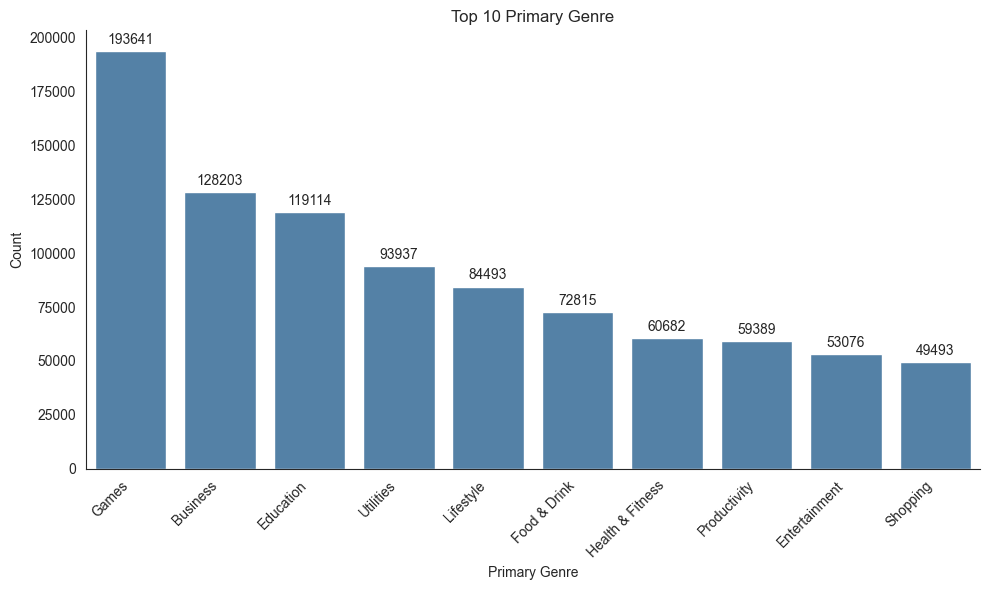

In [62]:
sns.set_style("white")                                                                  # Remove grid lines

plt.figure(figsize=(10,6))
ax = sns.barplot(x='Primary_Genre', y='Count', data=top_10_Genre, color='steelblue')

plt.title('Top 10 Primary Genre')
plt.xlabel('Primary Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

sns.despine()                                                                             # Remove spines of the plot

plt.tight_layout()
plt.show()


> **Figure 3:** Top 10 categories installed from the Apple Store.


---
**A1.** The top 10 categories installed from the Apple Store are:

1. Games
2. Business
3. Education
4. Utilities
5. Lifestyle
6. Food & Drink
7. Health & Fitness
8. Productivity
9. Entertainment
10. Shopping
---

**Q2. What are the top 10 highest-rated primary genres by average user rating?**

In [63]:
# Group the dataset by Primary_Genre and calculate the mean of Average_User_Rating for each group
mean_ratings = df.groupby('Primary_Genre')['Average_User_Rating'].mean()

# Sort the resulting Series in descending order
sorted_ratings = mean_ratings.sort_values(ascending=False)

# Select the top 10 entries
top_10 = sorted_ratings.head(10)

print(top_10)

Primary_Genre
Weather              2.622647
Games                2.566197
Photo & Video        2.316027
Music                2.264037
Book                 2.194122
Reference            2.191638
Finance              2.133502
Entertainment        2.026566
Social Networking    1.999213
Health & Fitness     1.859003
Name: Average_User_Rating, dtype: float64


In [ ]:
sns.set_style("white")

top_10_sorted = top_10.sort_values()

plt.figure(figsize=(10, 6))
ax = top_10_sorted.plot(kind='barh', color='steelblue')

plt.title('Top 10 Genres by Average User Rating', fontsize=16, fontweight='bold')
plt.xlabel('Average User Rating')
plt.ylabel('Primary Genre')
plt.xlim(0, top_10_sorted.max() * 1.15)

for i, v in enumerate(top_10_sorted):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()


> **Figure 4:** Top 10 genres by average user rating.


---
**A2.** By average user rating, the top 10 primary genres are:

1. Weather
2. Games
3. Photo & Video
4. Music
5. Book
6. Reference
7. Finance
8. Entertainment
9. Social Networking
10. Health & Fitness
---

**Q3. Which primary genre has the highest count of paid and free apps?**

In [64]:
# group the dataset by Primary_Genre and Type, and count the number of apps in each group
genre_counts = df.groupby(['Primary_Genre', 'Type']).size().reset_index(name='Count')

In [65]:
top_10_free_apps = genre_counts[genre_counts['Type'] == 'Free']                              # separate the free apps
top_10_free_genres = top_10_free_apps.sort_values(by='Count', ascending=False).head(10)       #load top 10 free apps

In [66]:
top10_paid_apps = genre_counts[genre_counts['Type'] == 'Paid']                               # separate the paid apps
top_10_paid_genres = top10_paid_apps.sort_values(by='Count', ascending=False).head(10)       #load top 10 paid apps

In [ ]:
top_10_free_genres.head(10).reset_index()

,Primary_Genre,Type,Count
14,Games,Free,177305
2,Business,Free,125443
6,Education,Free,101740
48,Utilities,Free,84217
20,Lifestyle,Free,81223
12,Food & Drink,Free,71935
18,Health & Fitness,Free,57290
34,Productivity,Free,53387
38,Shopping,Free,49238
8,Entertainment,Free,48977


In [ ]:
top_10_paid_genres.head(10).reset_index()

,Primary_Genre,Type,Count
7,Education,Paid,17374
15,Games,Paid,16336
49,Utilities,Paid,9720
45,Stickers,Paid,8865
35,Productivity,Paid,6002
27,Music,Paid,5367
33,Photo & Video,Paid,4861
9,Entertainment,Paid,4099
19,Health & Fitness,Paid,3392
37,Reference,Paid,3364


In [ ]:
sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

free_plot = top_10_free_genres.sort_values('Count')
axes[0].barh(free_plot['Primary_Genre'], free_plot['Count'], color='steelblue')
axes[0].set_title('Top 10 Genres — Free Apps', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Apps')

paid_plot = top_10_paid_genres.sort_values('Count')
axes[1].barh(paid_plot['Primary_Genre'], paid_plot['Count'], color='indianred')
axes[1].set_title('Top 10 Genres — Paid Apps', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Apps')

sns.despine()
plt.tight_layout()
plt.show()


> **Figure 5:** App count by genre — free vs. paid (top 10 each).


---
**A3.** Genres with the most **free** apps:

1. Games
2. Business
3. Education
4. Utilities
5. Lifestyle
6. Food & Drink
7. Health & Fitness
8. Productivity
9. Shopping
10. Entertainment

Genres with the most **paid** apps:

1. Education
2. Games
3. Utilities
4. Stickers
5. Productivity
6. Music
7. Photo & Video
8. Entertainment
9. Health & Fitness
10. Reference
---

**Q4. What are the top 5 paid apps by rating?**

In [69]:
#sort the paid app by rating in descending order and select the top 5
top_5_paid_apps = df[df['Type'] == 'Paid'].sort_values(by='Average_User_Rating', ascending=False).head(5)[['App_Name', 'Average_User_Rating']]

print(top_5_paid_apps)                                     # display the top 5 paid apps and their avg_user_ratings                                  

                              App_Name  Average_User_Rating
12                AA Big Book and More                    5
199             Gabe and the Pesky Bug                    5
32                 Aakkospeli Lapsille                    5
87               F&P Prompting Guide 1                    5
346783  Animal Fun for Toddlers & Kids                    5


In [ ]:
sns.set_style("white")

data = top_5_paid_apps.set_index('App_Name')['Average_User_Rating'].sort_values()

plt.figure(figsize=(10, 5))
ax = data.plot(kind='barh', color='steelblue')

plt.title('Top 5 Paid Apps by Average User Rating', fontsize=16, fontweight='bold')
plt.xlabel('Average User Rating')
plt.ylabel('')
plt.xlim(0, 5.5)

for i, v in enumerate(data):
    ax.text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()


> **Figure 6:** Top 5 paid apps by average user rating.


---
**A4.** Top 5 paid apps by rating:

1. Aakkospeli Lapsille
2. SystemLab - CPU Ram Battery
3. Syno DS Monitor
4. F&P Prompting Guide 1
5. Learn PHP Coding OFFLINE [PRO]
---

**Q5. What are the top 5 free apps by rating?**

In [70]:
# sort the paid apps by rating in descending order and select the top 5
top5_free_apps = df[df['Type'] == 'Free'].sort_values('Average_User_Rating', ascending=False).head(5)[['App_Name', 'Average_User_Rating']]

print(top5_free_apps)                                      # display the top 5 free apps and their avg_user_ratings

                             App_Name  Average_User_Rating
28                         AAB Mobile                    5
1230358           Sát hạch lái xe ôtô                    5
1230360       São Judas - Chama Aqui!                    5
33                Aalisiri Audiobooks                    5
39       Aarti Bhajan Chalisa Sangrah                    5


In [ ]:
sns.set_style("white")

data = top5_free_apps.set_index('App_Name')['Average_User_Rating'].sort_values()

plt.figure(figsize=(10, 5))
ax = data.plot(kind='barh', color='seagreen')

plt.title('Top 5 Free Apps by Average User Rating', fontsize=16, fontweight='bold')
plt.xlabel('Average User Rating')
plt.ylabel('')
plt.xlim(0, 5.5)

for i, v in enumerate(data):
    ax.text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()


> **Figure 7:** Top 5 free apps by average user rating.


---
**A5.** Top 5 free apps by rating:

1. BAAC eBook
2. A-Books
3. Melee Combat Art
4. Traverse: Explore Your World
5. Travis Martin's Weight Loss
---

**Q6. How are apps distributed across content ratings?**

In [71]:
# Group by Content_Rating and count apps
high_Content_Rating = df.groupby('Content_Rating').size().reset_index(name='Count')

# Now sort by Count
high_Content_Rating = high_Content_Rating.sort_values(by='Count', ascending=False)

print(high_Content_Rating)


  Content_Rating    Count
1       Children  1015768
0         Adults   123988
3          Teens    89497
2       Everyone       10


In [ ]:
sns.set_style("white")

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=high_Content_Rating,
    x='Content_Rating',
    y='Count',
    order=high_Content_Rating['Content_Rating'],
    color='steelblue'
)

plt.title('App Distribution by Content Rating', fontsize=16, fontweight='bold')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')

for i, v in enumerate(high_Content_Rating['Count']):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()


> **Figure 8:** App distribution by content rating.


---
**A6.** App counts by content rating, highest to lowest:

1. Children
2. Adults
3. Teens
4. Everyone
---

**Q7. In which years were the most apps released?**

In [ ]:
df['Released'] = pd.to_datetime(df['Released']) # convert to datetime format
df['Year_Release'] = df['Released'].dt.strftime('%Y')

Year_app_Release = df.groupby(['Year_Release']).size().reset_index(name='Count')
Year_app_Release.head(20).sort_values(by='Count', ascending=False).reset_index()

,Year_Release,Count
12,2020,227613
13,2021,217823
11,2019,165718
10,2018,134744
9,2017,126285
8,2016,120304
7,2015,78622
6,2014,55305
5,2013,39413
4,2012,27937


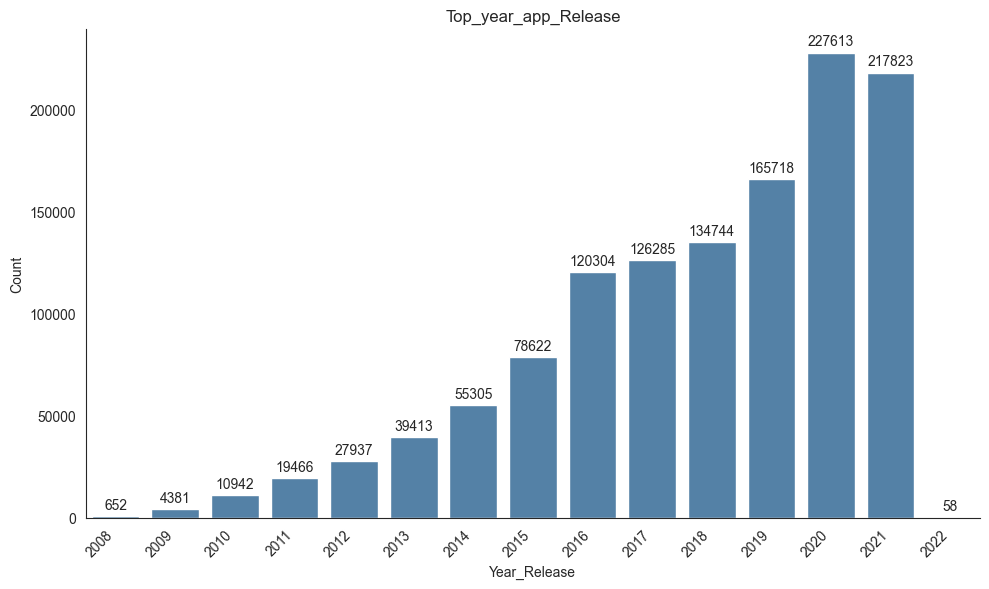

In [73]:
sns.set_style("white")                                                                  # Remove grid lines

plt.figure(figsize=(10,6))
ax = sns.barplot(x='Year_Release', y='Count', data=Year_app_Release, color='steelblue')

plt.title('Top_year_app_Release')
plt.xlabel('Year_Release')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

sns.despine()                                                                             # Remove spines of the plot

plt.tight_layout()
plt.show()


> **Figure 9:** App releases by year.


---
**A7.** 2020 saw the highest number of app releases — plausibly linked to increased demand during COVID-19 lockdowns.
---

**Q8. How does app size (MB) relate to price?**

In [74]:
Top_10_Apps_Size_Price = df.sort_values(by=['Size_MB', 'Price'], ascending=False).head(10)[['Size_MB', 'Price', 'App_Name']]
Top_10_Apps_Size_Price

,Size_MB,Price,App_Name
778214,73222.591724,39.99,Metro Exodus
762097,55966.684362,29.99,Total War: ROME REMASTERED
128518,46456.905587,39.99,Mafia III
762101,45104.025642,44.99,Total War: WARHAMMER II
762099,43870.335733,49.99,Total War: THREE KINGDOMS
668555,42760.803113,19.99,DiRT Rally
676183,40410.851272,35.99,Life is Strange 2
863396,40105.749650,39.99,Company of Heroes 2 Collection
663320,36724.346972,54.99,Shadow of the Tomb Raider
668510,35358.327187,24.99,DiRT 4


In [75]:
# you can plot like this for more detailed analysis

# # Plot Top 10 Apps by Size and Price
# plt.figure(figsize=(10,6))
# ax = sns.barplot(
#     x='Size_MB', 
#     y='Count', 
#     hue='Price', 
#     data=Top_10_Apps_Size_Price, 
#     palette='Blues'
# )

# plt.title('Top 10 Apps by Size and Price')
# plt.xlabel('App Size (MB)')
# plt.ylabel('Count')
# plt.xticks(rotation=45, ha='right')

# # Add labels on bars
# for container in ax.containers:
#     ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

# sns.despine()
# plt.tight_layout()
# plt.show()

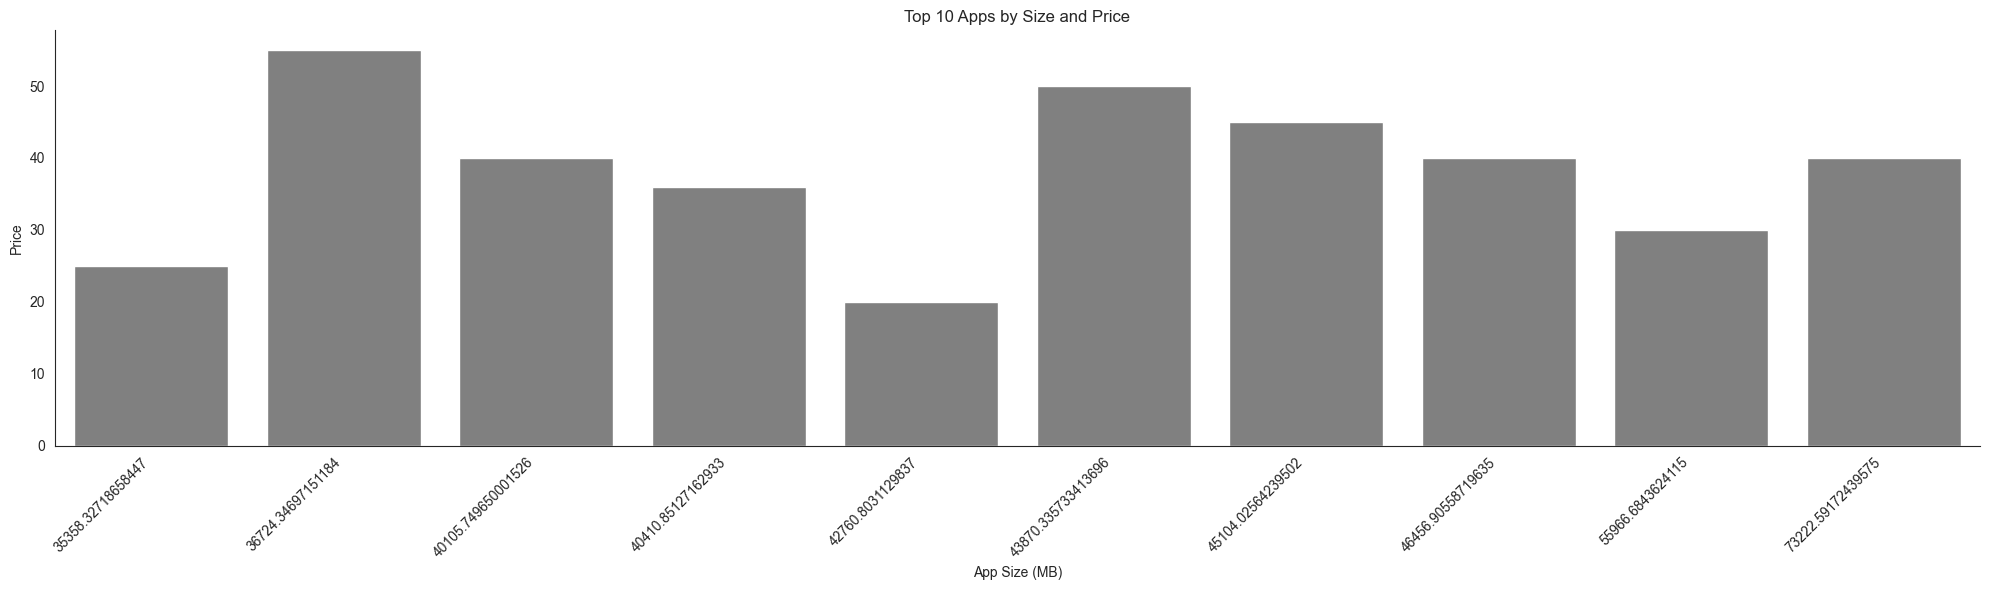

In [76]:
sns.barplot(Top_10_Apps_Size_Price, x='Size_MB', y='Price', color='grey')

plt.title('Top 10 Apps by Size and Price')
plt.xlabel('App Size (MB)')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
sns.despine()                                                                             # Remove spines of the plot
plt.show()


> **Figure 10:** App size (MB) vs. price, for the 10 largest apps.


In [77]:
# Correlation matrix for selected numeric columns
corr = df[['Size_MB', 'Price']].corr()
print(corr)

          Size_MB     Price
Size_MB  1.000000  0.056322
Price    0.056322  1.000000


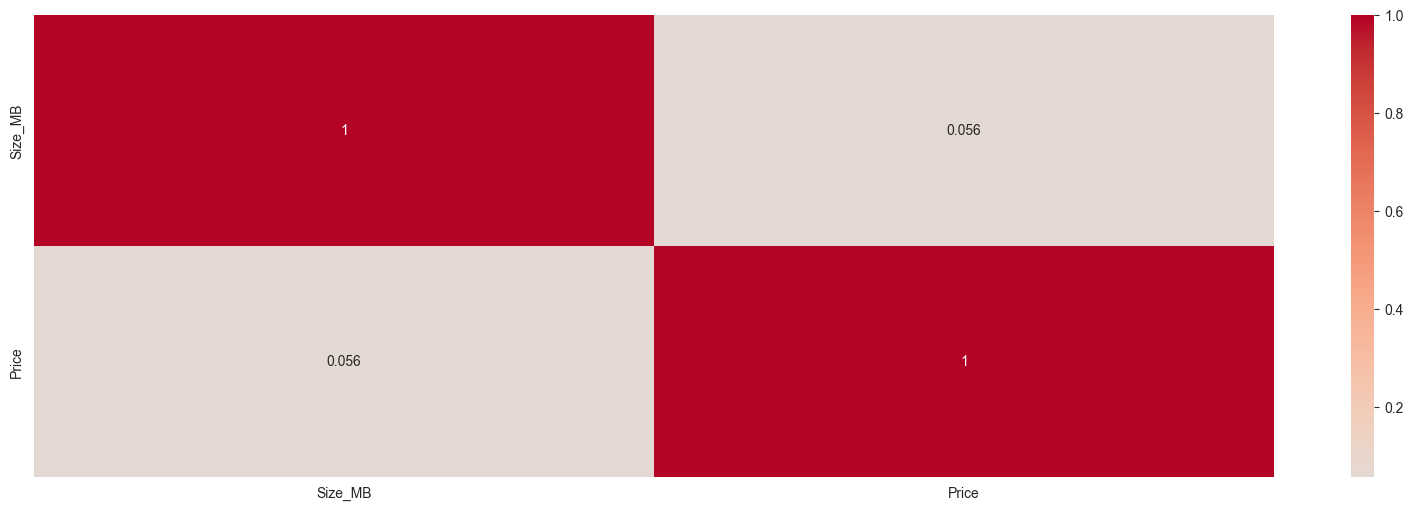

In [78]:
corr = df[['Size_MB', 'Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

> **Figure 11:** Correlation heatmap of app size and price.


---
**A8.** There's little direct or indirect correlation between app size and price — larger apps
generally aren't priced higher, with a small number of exceptions. Price doesn't scale with size.
---

**Q9. Who are the top 10 app-producing developers?**

In [79]:
# group the dataset by developer and count the number of apps
top_10_developer = df['Developer'].value_counts().reset_index(name='Count')
top_10_developer.sort_values(by='Count', ascending=False).head(10)

,Developer,Count
0,ChowNow,3966
1,Touch2Success,1649
2,Alexander Velimirovic,1506
3,"MINDBODY, Incorporated",1247
4,Phorest,1131
5,OFFLINE MAP TRIP GUIDE LTD,1022
6,Magzter Inc.,928
7,ASK Video,781
8,RAPID ACCELERATION INDIA PRIVATE LIMITED,733
9,Nonlinear Educating Inc.,555


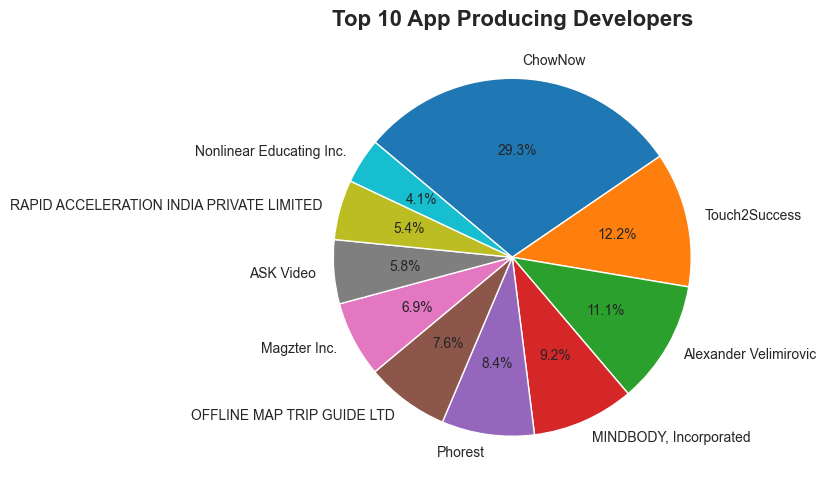

In [80]:
# Get top 10 developers by total app count
data = top_10_developer.groupby('Developer')['Count'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))
plt.pie(
    data, 
    labels=data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    counterclock=False, 
    wedgeprops={'edgecolor':'white'}
)

plt.title("Top 10 App Producing Developers", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


> **Figure 12:** Top 10 developers by app count (share of total).


- The same breakdown as a bar chart:

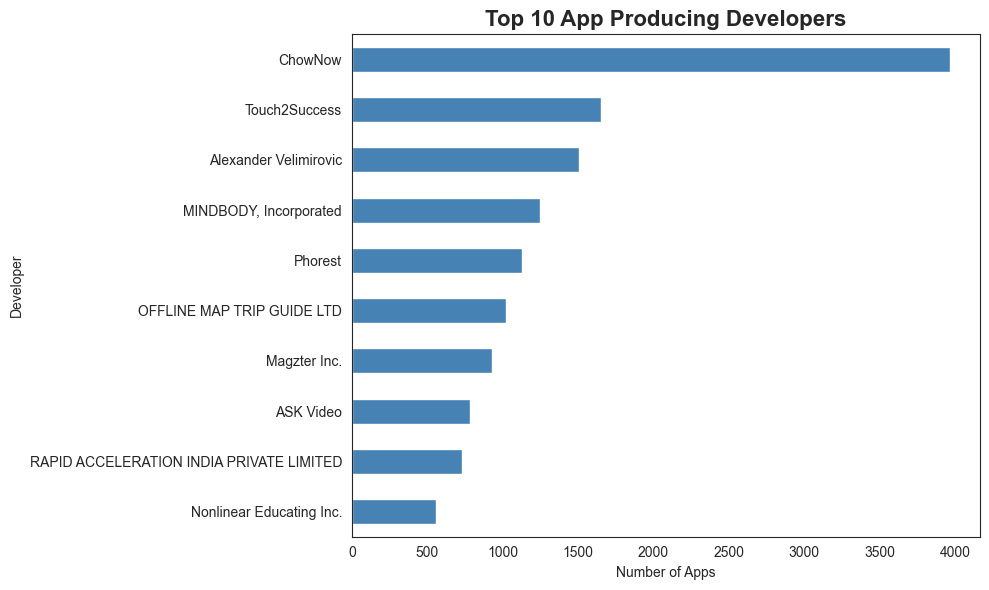

In [81]:
# Get top 10 developers by app count
data = top_10_developer.groupby('Developer')['Count'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
data.plot(kind='barh', color='steelblue')

plt.title("Top 10 App Producing Developers", fontsize=16, fontweight='bold')
plt.xlabel("Number of Apps")
plt.ylabel("Developer")
plt.gca().invert_yaxis()  # Largest at the top
plt.tight_layout()
plt.show()


> **Figure 13:** Top 10 developers by app count.


---
**A9.** Top 10 app-producing developers:

1. ChowNow
2. Touch2Success
3. Alexander Velimirovic
4. MINDBODY, Incorporated
5. Phorest
6. OFFLINE MAP TRIP GUIDE LTD
7. Magzter Inc.
8. ASK Video
9. RAPID ACCELERATION INDIA PRIVATE LIMITED
10. Nonlinear Educating Inc.
---

**Q10. Which genres attract which type of clientele in terms of revenue?**

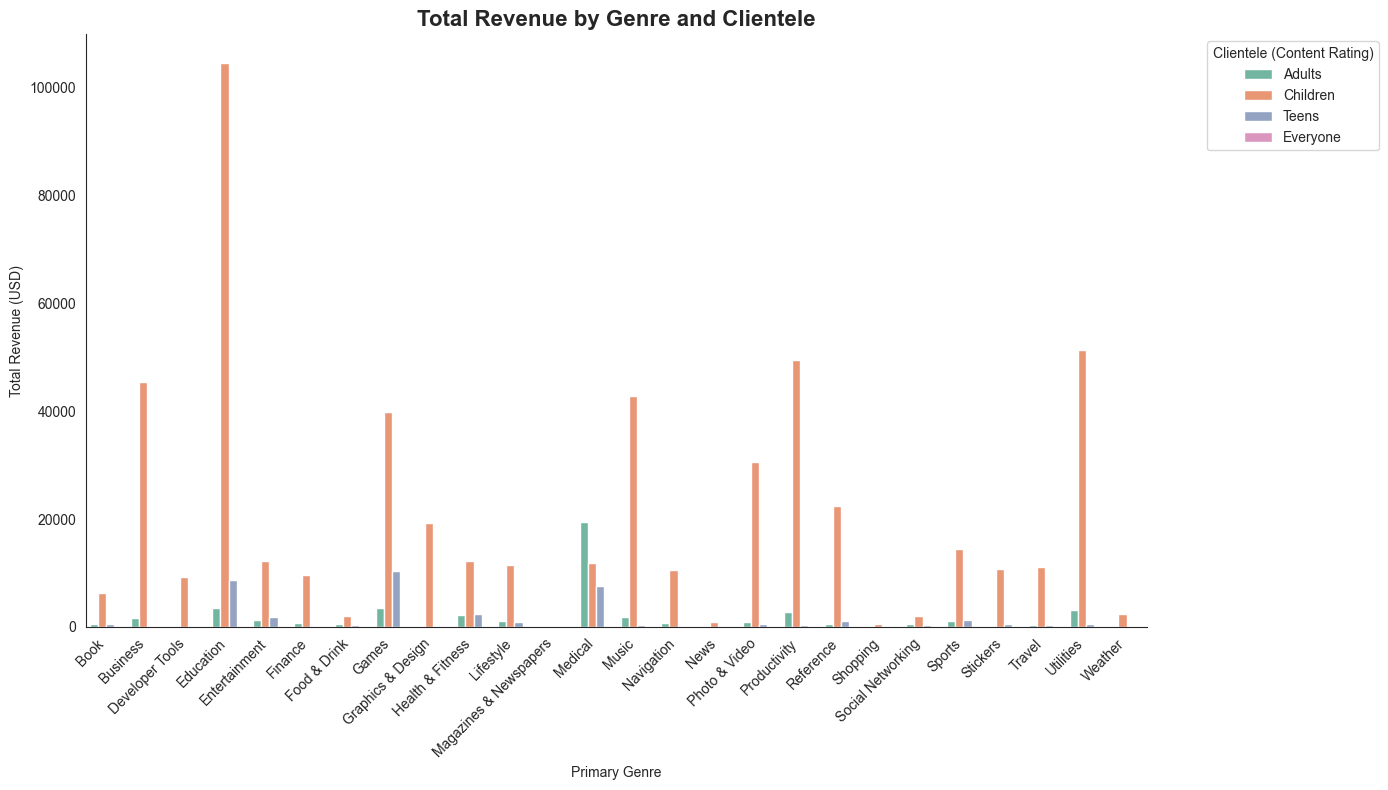

In [82]:
# Step 1: Create Type column (Free vs Paid)
df['Type'] = df['Price'].apply(lambda x: 'Free' if x == 0 else 'Paid')

# Step 2: Compute total revenue per Genre + Clientele
df['Revenue'] = df['Price']   # assuming Price is the app price in USD
genre_clientele_revenue = (
    df.groupby(['Primary_Genre', 'Content_Rating'])
      .agg(
          Total_Apps=('App_Id', 'size'),
          Total_Revenue=('Revenue', 'sum'),
          Avg_Price=('Price', 'mean')
      )
      .reset_index()
)

# Step 3: Stacked bar plot for total revenue
plt.figure(figsize=(14,8))
ax = sns.barplot(
    x='Primary_Genre',
    y='Total_Revenue',
    hue='Content_Rating',
    data=genre_clientele_revenue,
    palette='Set2'
)

plt.title("Total Revenue by Genre and Clientele", fontsize=16, fontweight='bold')
plt.xlabel("Primary Genre")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Clientele (Content Rating)', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()


> **Figure 14:** Total revenue by genre and clientele (content rating).


**A10.** A few points stand out that warrant closer attention — notably, which Business &
Utilities apps are bought by (or for) children.

**Caveats:**
- ⚠️ The `Content_Rating` attribute isn't always reliable.
- 🚸 An app rated "9+" can still contain inappropriate content — e.g., an e-book with mature themes.

In [83]:
# select the rows where Content_Rating is Toddlers and Primary_Genre is Business
toddler_business_df = df[(df['Content_Rating'] == 'Children') & (df['Primary_Genre'] == 'Business')]

# print the resulting DataFrame
toddler_business_df.head(5)

,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,Price,Currency,DeveloperId,Developer,Developer_Url,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews,Size_MB,Type,Review_Category,Year_Release,Revenue
528,com.lettechnologies.Hadith-Collection-Pro,Hadith Collection English,https://apps.apple.com/us/app/hadith-collectio...,Business,Children,443802624.0,11.0,2021-01-15 08:00:00+00:00,2021-01-15T22:53:46Z,1.0,0.99,USD,1097519044,Akhzar Nazir,https://apps.apple.com/us/developer/akhzar-naz...,0,0,0.0,0,423.243164,Paid,No_Reviews_Provided,2021,0.99
565,com.thos.thoshukuk,T-HOS,https://apps.apple.com/us/app/t-hos/id13329939...,Business,Children,20775936.0,10.1,2018-02-12 18:36:26+00:00,2021-09-17T10:05:06Z,1.9,0.00,USD,1332993964,THOS HUKUK OTOMASYON SISTEMLERI YAZILIM ANONIM...,https://apps.apple.com/us/developer/thos-hukuk...,0,0,0.0,0,19.813477,Free,No_Reviews_Provided,2018,0.00
569,tr.gov.tccb.mevzuatbilgisistemi,T.C. Mevzuat Bilgi Sistemi,https://apps.apple.com/us/app/t-c-mevzuat-bilg...,Business,Children,12931072.0,10.0,2019-11-22 08:00:00+00:00,2021-06-17T10:02:27Z,1.4.1,0.00,USD,458584330,Türkiye Cumhuriyeti Cumhurbaşkanlığı,https://apps.apple.com/us/developer/t%C3%BCrki...,5,1,5.0,1,12.332031,Free,Less than 10K,2019,0.00
850,tr.gov.tccb.resmigazete,T.C. Resmi Gazete,https://apps.apple.com/us/app/t-c-resmi-gazete...,Business,Children,15455232.0,10.0,2019-07-14 08:39:38+00:00,2021-07-01T18:40:48Z,2.2.3,0.00,USD,458584330,Türkiye Cumhuriyeti Cumhurbaşkanlığı,https://apps.apple.com/us/developer/t%C3%BCrki...,3,2,3.0,2,14.739258,Free,Less than 10K,2019,0.00
885,app.kickpro.ubonbookfair,Ubon Book Fair ครั้งที่ 11,https://apps.apple.com/us/app/ubon-book-fair-%...,Business,Children,55010304.0,10.0,2019-08-05 07:00:00+00:00,2019-08-05T07:00:00Z,1.0,0.00,USD,501928215,Digital Insider Company Limited,https://apps.apple.com/us/developer/digital-in...,0,0,0.0,0,52.461914,Free,No_Reviews_Provided,2019,0.00


**Q11. How do app releases per content rating compare year-on-year?**

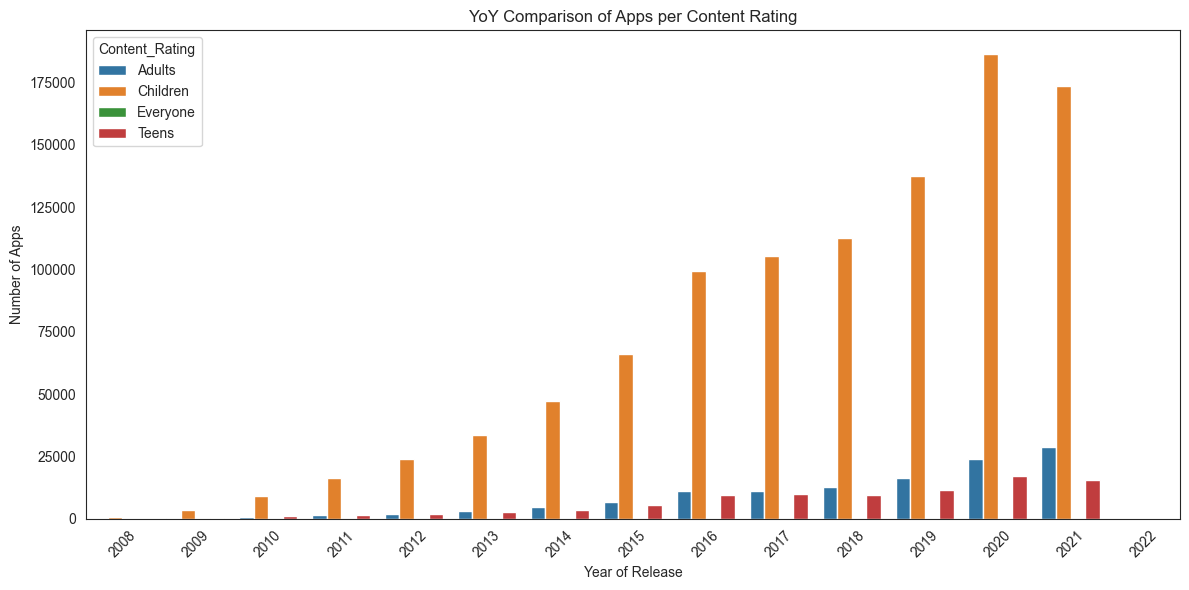

In [84]:

# Step 1: Convert Released to year only
df['Release_Year'] = pd.to_datetime(df['Released'], errors='coerce').dt.year

# Step 2: Group by year and content rating
cnt_summary = (
    df.groupby(['Release_Year', 'Content_Rating'])
      .size()
      .reset_index(name='Count')
)

# Step 3: Plot YoY comparison
plt.figure(figsize=(12,6))
sns.barplot(data=cnt_summary, x='Release_Year', y='Count', hue='Content_Rating')
plt.title("YoY Comparison of Apps per Content Rating")
plt.xlabel("Year of Release")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Figure 15:** Year-on-year app releases by content rating.


---
**A11.** The Children category clearly leads. As noted above, though, some non-children's apps
are also mis-classified under the Children rating.
---

**Q12. How does user rating relate to price?**

<Axes: xlabel='Year_Release'>

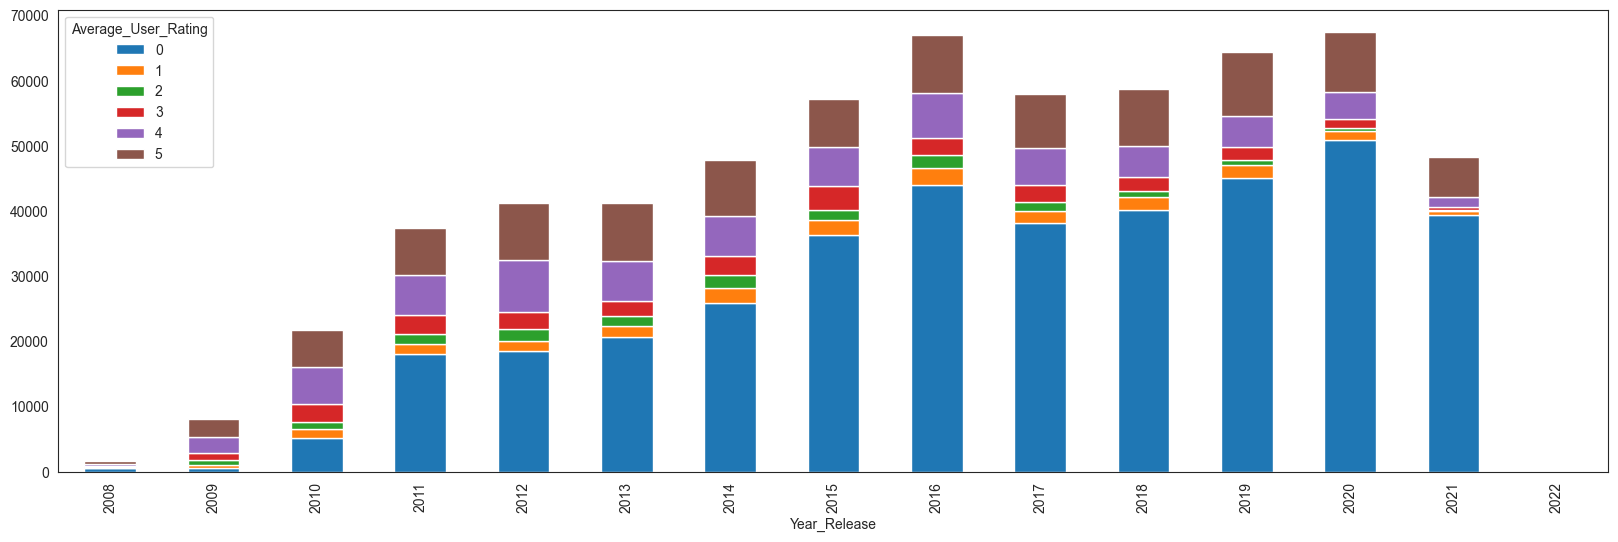

In [85]:
usr_Rat_Pri = df.groupby(['Average_User_Rating', 'Year_Release'])[['Price']].sum()


usr_Rat_Pri.groupby(['Year_Release', 'Average_User_Rating'])['Price'].sum().unstack().plot(kind='bar', stacked=True)

> **Figure 16:** User rating vs. price, by release year.


---
**A12.** Higher-rated apps tend to be priced higher.
---

**Q13. How does user rating relate to app size (MB)?**

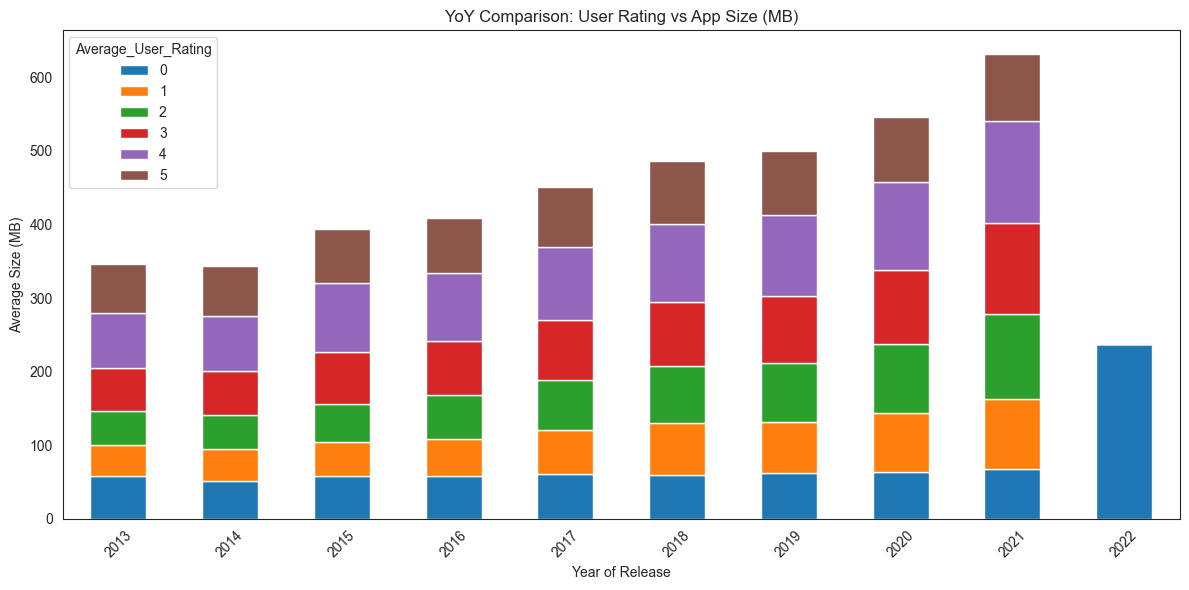

In [86]:
# Step 1: Convert Released to year only
df['Release_Year'] = pd.to_datetime(df['Released'], errors='coerce').dt.year

# Step 2: Aggregate average Size_MB per rating per year
usr_Rat_MB = (
    df.groupby(['Release_Year', 'Average_User_Rating'])['Size_MB']
      .mean()   # use mean instead of sum to keep values small
      .reset_index()
)

# Step 3: Pivot for plotting
pivot = usr_Rat_MB.pivot(index='Release_Year', columns='Average_User_Rating', values='Size_MB')

# Step 4: Plot stacked bar chart (limit to last 10 years)
pivot_recent = pivot.tail(10)

pivot_recent.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("YoY Comparison: User Rating vs App Size (MB)")
plt.xlabel("Year of Release")
plt.ylabel("Average Size (MB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


> **Figure 17:** User rating vs. average app size (MB), by release year.


---
**A13.** Higher-rated apps tend to be larger in size (MB).
---

**Q14. How does revenue break down year-on-year by top-5 genre?**

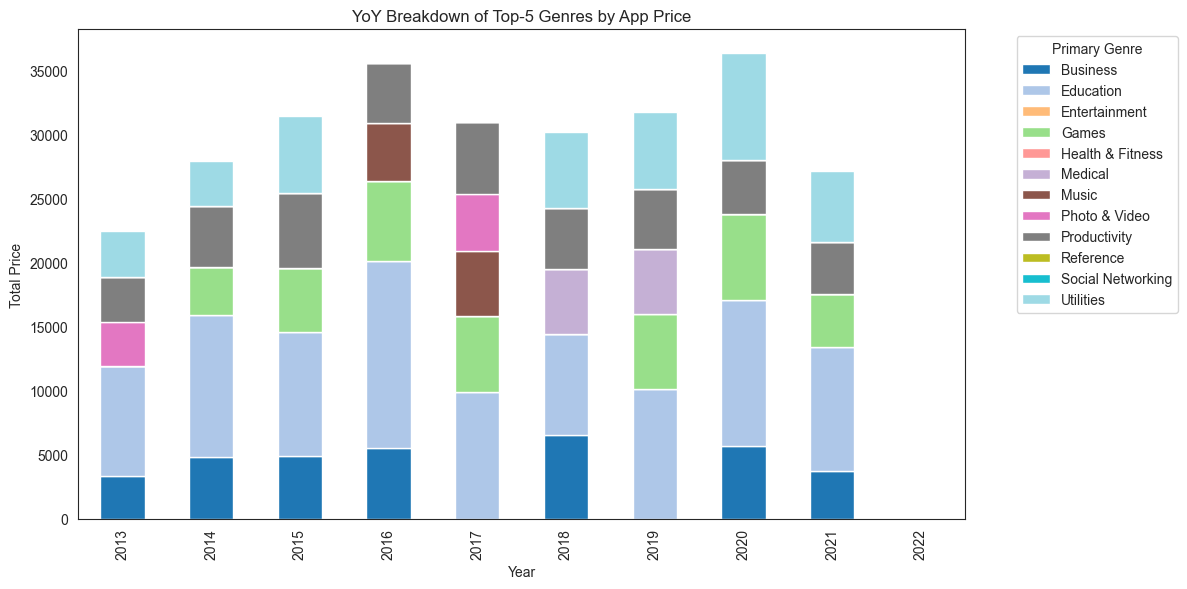

In [87]:
# Step 1: Convert Released to year only
df['Release_Year'] = pd.to_datetime(df['Released'], errors='coerce').dt.year

# Step 2: Aggregate revenue (sum of Price) per year × genre
rev_per_genre = (
    df.groupby(['Release_Year','Primary_Genre'])['Price']
      .sum()
      .reset_index()
)

# Step 3: For each year, keep only top 5 genres
top5 = (
    rev_per_genre.sort_values(['Release_Year','Price'], ascending=[True,False])
    .groupby('Release_Year')
    .head(5)
)

# Step 4: Pivot for stacked bar chart
pivot = top5.pivot(index='Release_Year', columns='Primary_Genre', values='Price').fillna(0)

# Step 5: Plot (limit to last 10 years for readability)
pivot_recent = pivot.tail(10)

pivot_recent.plot(kind='bar', stacked=True, figsize=(12,6), cmap='tab20')
plt.title("YoY Breakdown of Top-5 Genres by App Price")
plt.xlabel("Year")
plt.ylabel("Total Price")
plt.legend(title='Primary Genre', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


> **Figure 18:** Year-on-year revenue breakdown by top 5 genres.


---
**A14.** Educational apps consistently contribute the most revenue among the top genres.
---

**Q15. How are apps distributed across required iOS versions?**

<Axes: xlabel='Required_IOS_Version', ylabel='Count'>

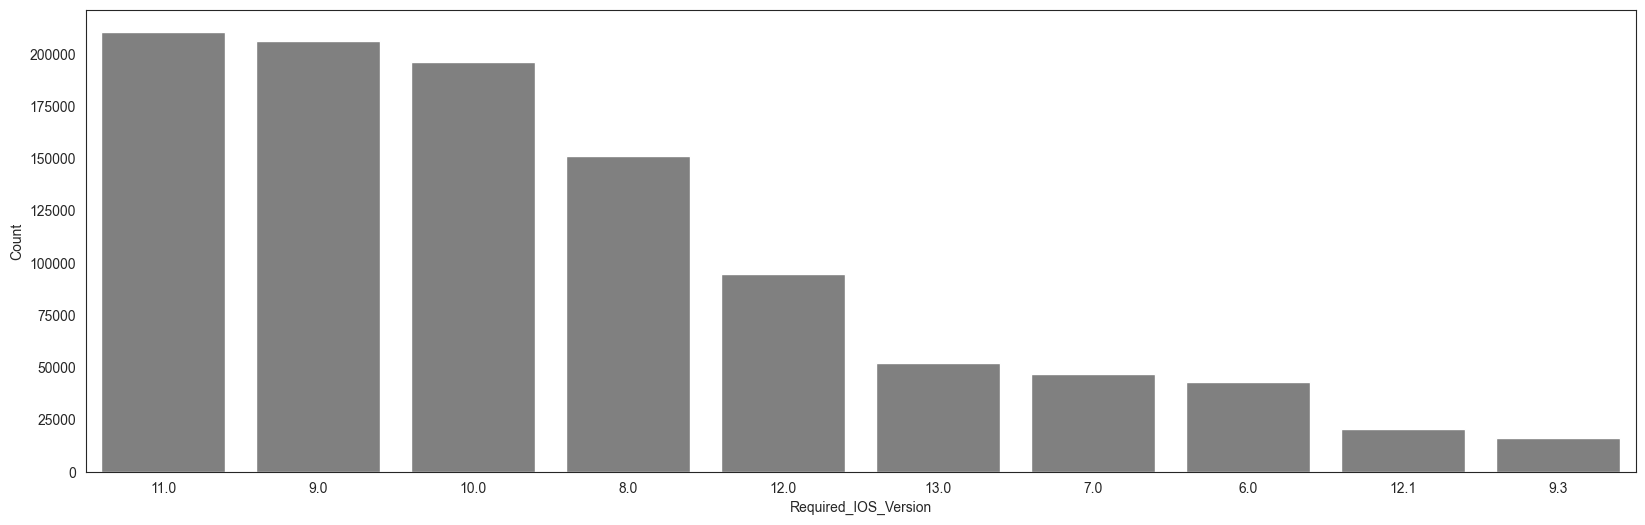

In [88]:
# group the dataset by Primary_Genre and Type, and count the number of apps in each group
Ver_counts = df.groupby(['Required_IOS_Version']).size().reset_index(name='Count')

# ##load top 10 free apps
top_10_Ver_counts = Ver_counts.sort_values(by='Count', ascending=False).head(10)

sns.barplot(top_10_Ver_counts , x='Required_IOS_Version', y='Count', color='grey')

> **Figure 19:** App count by required iOS version (top 10).


---
**A15.** App counts are concentrated in a handful of mid-range, widely-adopted iOS versions.
---

**Q16. How do the numeric attributes correlate with each other?**

In [89]:
df.describe()

,Size_Bytes,Price,DeveloperId,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews,Size_MB,Revenue,Release_Year
count,1.229263e+06,1.229263e+06,1.229263e+06,1.229263e+06,1.229263e+06,1.229263e+06,1.229263e+06,1.229263e+06,1.229263e+06,1.229263e+06
mean,7.511111e+07,5.045459e-01,1.092483e+09,1.796379e+00,8.266250e+02,1.788848e+00,8.266250e+02,7.163154e+01,5.045459e-01,2.017851e+03
std,2.319421e+08,6.871388e+00,4.090210e+08,2.169981e+00,5.018320e+04,2.154179e+00,5.018320e+04,2.211973e+02,6.871388e+00,2.746886e+00
min,2.762800e+04,0.000000e+00,2.816565e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.634811e-02,0.000000e+00,2.008000e+03
25%,2.041139e+07,0.000000e+00,7.374160e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.946582e+01,0.000000e+00,2.016000e+03
50%,4.332646e+07,0.000000e+00,1.178976e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.131934e+01,0.000000e+00,2.018000e+03
75%,8.365261e+07,0.000000e+00,1.471522e+09,4.000000e+00,3.000000e+00,4.333330e+00,3.000000e+00,7.977734e+01,0.000000e+00,2.020000e+03
max,7.677945e+10,9.999900e+02,1.590203e+09,5.000000e+00,2.268533e+07,5.000000e+00,2.268533e+07,7.322259e+04,9.999900e+02,2.022000e+03


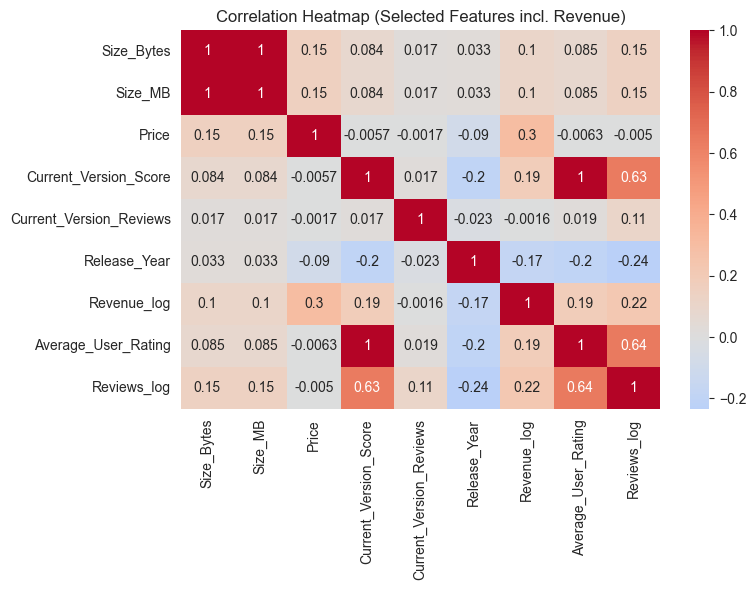

In [90]:
# Step 0: Create Release_Year column if not already present
df['Release_Year'] = pd.to_datetime(df['Released'], errors='coerce').dt.year

# Step 1: Define Revenue (Price × Reviews)
df['Revenue'] = df['Price'] * df['Reviews']

# Step 2: Apply log transform to reduce skew
df['Revenue_log'] = np.log1p(df['Revenue'])
df['Reviews_log'] = np.log1p(df['Reviews'])

# Step 3: Select numeric columns (exclude DeveloperId)
numeric_cols = [
    'Size_Bytes','Size_MB','Price',
    'Current_Version_Score','Current_Version_Reviews',
    'Release_Year','Revenue_log','Average_User_Rating','Reviews_log'
]

# Step 4: Sample rows to avoid memory overload
sample_df = df[numeric_cols].sample(n=10000, random_state=42)

# Step 5: Compute correlation matrix
corr = sample_df.corr()

# Step 6: Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, cbar=True, cmap='coolwarm', annot=True, center=0)
plt.title("Correlation Heatmap (Selected Features incl. Revenue)")
plt.tight_layout()
plt.show()


> **Figure 20:** Correlation matrix of numeric attributes.


---
**A16.**
- The only genuinely strong correlations are structural (`Size_MB` vs. `Size_Bytes`) or definitional (`Revenue` vs. `Reviews`).
- Moderate correlation exists between revenue, price, and review counts.
- Ratings and app size have little effect on revenue.
- `DeveloperId` is essentially noise and should be excluded from correlation analysis.
---

---
## Part 3 · Summary

This EDA of the Apple App Store dataset surfaced a range of actionable insights. The dataset was
relatively clean and consistent throughout. Key findings, mapped back to the business questions:

**Q1 – Top categories:** Games are the most downloaded apps on the store.

**Q2 – Top-rated genres:** Weather, Games, Photo & Video, Music, Books, and Reference lead on average user rating.

**Q3 – Free vs. paid leaders:** Free apps skew toward Games, Business, Education, Utilities, and Lifestyle; paid apps skew toward Education, Games, Utilities, Stickers, and Productivity.

**Q4/Q5 – Top-rated apps:** A long tail of niche paid and free apps hold the highest ratings (see the full Q&A section for the named apps).

**Q6 – Content rating distribution:** Apps skew toward the Children rating bucket, though see the reliability caveat below.

**Q7 – Release timing:** 2020 saw the most app releases, plausibly a COVID-19 effect.

**Q8 – Size vs. price:** App size is largely irrelevant to price.

**Q9 – Top developers:** ChowNow, Touch2Success, Alexander Velimirovic, MINDBODY, Phorest, and others lead in app output.

**Q10 – Genre vs. clientele:** Some Business & Utilities apps are marketed to or used by children — worth further investigation given known unreliability in the content rating field.

**Q11 – YoY content rating trend:** The Children category leads, with the same rating-reliability caveat as Q10.

**Q12/Q13 – Rating vs. price/size:** Higher-rated apps trend toward higher price and larger size.

**Q14 – Revenue by genre:** Educational apps contribute disproportionately more revenue.

**Q15 – iOS version distribution:** App counts concentrate in a handful of widely-adopted iOS versions.

**Q16 – Attribute correlation:** Beyond structural/definitional pairs, correlations across numeric attributes are weak to moderate; `DeveloperId` carries no signal.

---

## Conclusion & Recommendations

The goal of this project was to analyze the Apple App Store dataset and surface insights that help
developers and stakeholders understand customer dynamics and prioritize where to invest.

**Data quality milestones:**
- All null values were resolved (imputed where meaningful, dropped where unrecoverable).
- No true duplicate records were found — repeated `App_Name` values reflect distinct apps
  (different versions, `App_Id`s, and release dates), not data errors.

**Headline findings:**
- Games dominate downloads and app volume across both free and paid segments.
- Weather, Games, and Photo & Video genres earn the highest average user ratings.
- Educational apps punch above their weight on revenue relative to volume.
- App size is a weak predictor of price; user rating is a better (if still moderate) one.

**Caveat for future work:** the `Content_Rating` attribute is not fully reliable — a "9+" label
doesn't guarantee age-appropriate content (e.g., e-books with mature themes have been observed
under lenient ratings). Any downstream use of this field for content moderation or targeting
should be validated further before being treated as ground truth.


----